Data Loading and Initial Exploration

In [ ]:
# Phase 1: Data Loading and Initial Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, normaltest
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('/content/us_citizens_1000.csv')

print("=== PHASE 1: DATA LOADING AND INITIAL EXPLORATION ===")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe(include='all'))

print("\nMissing values:")
print(df.isnull().sum())

# Check for empty strings
print("\nEmpty string counts:")
for col in df.columns:
    if df[col].dtype == 'object':
        empty_count = (df[col] == '').sum()
        print(f"{col}: {empty_count}")


=== PHASE 1: DATA LOADING AND INITIAL EXPLORATION ===
Dataset shape: (1000, 10)
Columns: ['National_ID', 'Name', 'Surname', 'Date_of_Birth', 'Residential_Address', 'Mailing_Address', 'Citizenship_Status', 'Email', 'Contact_Phone', 'Signature']

First 5 rows:
   National_ID      Name   Surname Date_of_Birth  \
0    126855092  Danielle   Johnson    10/10/1985   
1    732719211  Brittany   Johnson    03/01/2007   
2    506448196    Robert      Cole    06/11/1981   
3    491735568     Helen  Peterson    11/15/1975   
4    787194506    Curtis     James    01/16/1988   

                       Residential_Address  \
0         3658 Pine Rd, Johnberg, WV 97031   
1  2616 First St, East Jessetown, MI 74064   
2   5926 Washington St, Lisatown, IL 21427   
3       3433 Elm Way, East Susan, VT 44619   
4      5314 Main St, Melanieview, IA 06196   

                          Mailing_Address    Citizenship_Status  \
0     PO Box 9035, Lake Joyside, CO 11896               Citizen   
1       PO Box 36

In [ ]:
df.head()

,National_ID,Name,Surname,Date_of_Birth,Residential_Address,Mailing_Address,Citizenship_Status,Email,Contact_Phone,Signature
0,126855092,Danielle,Johnson,10/10/1985,"3658 Pine Rd, Johnberg, WV 97031","PO Box 9035, Lake Joyside, CO 11896",Citizen,danielle.johnson55@example.org,8162274257,ecce782cd4a32b88be3d6b0b9c857c3a647a64b49d1a9e...
1,732719211,Brittany,Johnson,03/01/2007,"2616 First St, East Jessetown, MI 74064","PO Box 3627, Lake Debra, WI 71927",Non-Resident Citizen,brittany.johnson56@example.net,8184701711,782dc7432ed2d65aa5c26ea494f643f747f35f4c8abc76...
2,506448196,Robert,Cole,06/11/1981,"5926 Washington St, Lisatown, IL 21427","5926 Washington St, Lisatown, IL 21427",Citizen,robert.cole68@example.com,3035895554,eac54897c8d4daaac9049cbd7a35f601528c25f82a3d8e...
3,491735568,Helen,Peterson,11/15/1975,"3433 Elm Way, East Susan, VT 44619","3433 Elm Way, East Susan, VT 44619",Citizen,helen.peterson60@yahoo.com,367.673.7216,717b53faac8e89cef548056b48e45c90aedf2136b31f6f...
4,787194506,Curtis,James,01/16/1988,"5314 Main St, Melanieview, IA 06196","5314 Main St, Melanieview, IA 06196",Citizen,curtis.james54@example.org,780-935-6155,8e7fd1209015fb24fd748a2d257c1444e6ed09a7fd97c7...


Data Preprocessing

In [ ]:
# Phase 1: Data Preprocessing
print("\n=== PHASE 1: DATA PREPROCESSING ===")

# Create a copy for preprocessing
df_clean = df.copy()

# 1. Parse Date of Birth and calculate Age
df_clean['DOB_parsed'] = pd.to_datetime(df_clean['Date_of_Birth'], errors='coerce')
current_date = pd.Timestamp.now()
df_clean['Age'] = ((current_date - df_clean['DOB_parsed']).dt.days / 365.25).round(1)

# 2. Extract State from Residential Address
df_clean['State'] = df_clean['Residential_Address'].str.extract(r', ([A-Z]{2}) ')

# 3. Clean Phone Numbers (extract digits only)
df_clean['Phone_Digits'] = df_clean['Contact_Phone'].astype(str).str.replace(r'\D', '', regex=True)
df_clean['Phone_Length'] = df_clean['Phone_Digits'].str.len()

# 4. Email validation flags
# Handle missing emails before applying string operations
email_not_missing = df_clean['Email'].notna()
df_clean['Email_Valid'] = email_not_missing & ~df_clean.loc[email_not_missing, 'Email'].str.endswith('@') & (df_clean.loc[email_not_missing, 'Email'] != '') & df_clean.loc[email_not_missing, 'Email'].str.contains('@')
df_clean['Email_Missing'] = ~email_not_missing | (df_clean['Email'] == '')

# 5. Address mismatch flag
df_clean['Address_Mismatch'] = df_clean['Residential_Address'] != df_clean['Mailing_Address']

# 6. National ID analysis
df_clean['National_ID_Length'] = df_clean['National_ID'].astype(str).str.len()
df_clean['National_ID_FirstDigit'] = df_clean['National_ID'].astype(str).str[0].astype(int)

print("Preprocessing completed. New columns added:")
print(['Age', 'State', 'Phone_Digits', 'Phone_Length', 'Email_Valid', 'Email_Missing',
       'Address_Mismatch', 'National_ID_Length', 'National_ID_FirstDigit'])

print(f"\nAge statistics:")
print(df_clean['Age'].describe())

print(f"\nPhone length distribution:")
print(df_clean['Phone_Length'].value_counts().sort_index())


=== PHASE 1: DATA PREPROCESSING ===
Preprocessing completed. New columns added:
['Age', 'State', 'Phone_Digits', 'Phone_Length', 'Email_Valid', 'Email_Missing', 'Address_Mismatch', 'National_ID_Length', 'National_ID_FirstDigit']

Age statistics:
count    1000.000000
mean       51.480200
std        19.800792
min        14.600000
25%        34.750000
50%        51.650000
75%        68.100000
max        99.000000
Name: Age, dtype: float64

Phone length distribution:
Phone_Length
6       3
7       6
10    991
Name: count, dtype: int64


Duplicate Detection

In [ ]:
# Phase 1: Duplicate Detection
print("\n=== PHASE 1: DUPLICATE DETECTION ===")

# Check for duplicate National IDs
duplicate_ids = df_clean[df_clean['National_ID'].duplicated(keep=False)]
print(f"Records with duplicate National IDs: {len(duplicate_ids)}")

if len(duplicate_ids) > 0:
    print("\nDuplicate National ID records:")
    print(duplicate_ids[['National_ID', 'Name', 'Surname', 'Age', 'State']].sort_values('National_ID'))

# Check for potential duplicate persons (same name, similar age)
potential_duplicates = df_clean.groupby(['Name', 'Surname']).filter(lambda x: len(x) > 1)
print(f"\nRecords with same Name+Surname: {len(potential_duplicates)}")

if len(potential_duplicates) > 0:
    print(potential_duplicates[['Name', 'Surname', 'National_ID', 'Age']].sort_values(['Name', 'Surname']))

# Summary of duplicates
print(f"\nDuplicate Summary:")
print(f"- Unique National IDs: {df_clean['National_ID'].nunique()}")
print(f"- Total records: {len(df_clean)}")
print(f"- Duplicate National IDs: {len(df_clean) - df_clean['National_ID'].nunique()}")



=== PHASE 1: DUPLICATE DETECTION ===
Records with duplicate National IDs: 8

Duplicate National ID records:
     National_ID     Name   Surname   Age State
50     123456789    Kevin      Pope  40.4    IA
550    123456789     Mary       Lee  45.6    NY
650    234567890  Melissa   Parsons  46.7    AR
150    234567890    Mario  Thompson  66.5    WI
750    345678901   Autumn    Romero  59.3    MD
250    345678901      Amy      Lowe  67.5    WV
350    456789012   Donald   Edwards  45.8    WY
850    456789012  Richard    Porter  21.7    MD

Records with same Name+Surname: 8
         Name Surname  National_ID   Age
35      Brian  Romero    295130056  52.0
177     Brian  Romero    704829337  16.5
627   Michael   Green    314180354  23.8
993   Michael   Green    874428419  40.8
28   Michelle   Brown    825449223  60.4
926  Michelle   Brown    911136966  39.6
618    Robert   White    214315434  71.6
941    Robert   White    280970231  70.5

Duplicate Summary:
- Unique National IDs: 996
- Total 

Outlier Detection

In [ ]:
# Phase 1: Outlier Detection
print("\n=== PHASE 1: OUTLIER DETECTION ===")

# Age outliers using IQR method
Q1_age = df_clean['Age'].quantile(0.25)
Q3_age = df_clean['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

age_outliers = df_clean[(df_clean['Age'] < lower_bound_age) | (df_clean['Age'] > upper_bound_age)]
print(f"Age outliers (IQR method): {len(age_outliers)}")
print(f"Age bounds: [{lower_bound_age:.1f}, {upper_bound_age:.1f}]")

if len(age_outliers) > 0:
    print("Age outlier records:")
    print(age_outliers[['National_ID', 'Name', 'Surname', 'Age', 'Citizenship_Status']])

# Voting eligibility outliers
underage = df_clean[df_clean['Age'] < 18]
very_elderly = df_clean[df_clean['Age'] > 90]

print(f"\nVoting eligibility outliers:")
print(f"- Underage (<18): {len(underage)}")
print(f"- Very elderly (>90): {len(very_elderly)}")

# Phone length outliers
phone_outliers = df_clean[df_clean['Phone_Length'] != 10]
print(f"\nPhone format outliers (not 10 digits): {len(phone_outliers)}")

# Create outlier summary flag
df_clean['Is_Outlier'] = (
    (df_clean['Age'] < 18) |
    (df_clean['Age'] > 90) |
    (df_clean['Phone_Length'] != 10) |
    (df_clean['National_ID'].duplicated(keep=False)) |
    (~df_clean['Email_Valid'] & ~df_clean['Email_Missing'])
)

print(f"\nTotal records flagged as outliers: {df_clean['Is_Outlier'].sum()}")



=== PHASE 1: OUTLIER DETECTION ===
Age outliers (IQR method): 0
Age bounds: [-15.3, 118.1]

Voting eligibility outliers:
- Underage (<18): 7
- Very elderly (>90): 6

Phone format outliers (not 10 digits): 9

Total records flagged as outliers: 39


Statistical Analysis - Benford's Law


=== PHASE 2: BENFORD'S LAW ANALYSIS ===
Benford's Law Analysis for National ID First Digits:
Digit	Observed	Expected	Difference
1	12.4%		30.1%		-17.7%
2	13.4%		17.6%		-4.2%
3	9.4%		12.5%		-3.1%
4	11.4%		9.7%		+1.7%
5	10.4%		7.9%		+2.5%
6	9.6%		6.7%		+2.9%
7	11.3%		5.8%		+5.5%
8	11.6%		5.1%		+6.5%
9	10.5%		4.6%		+5.9%

Chi-square statistic: 355.91
P-value: 4.96e-72
Critical value (α=0.05): 15.51
Benford's Law compliance: FAIL


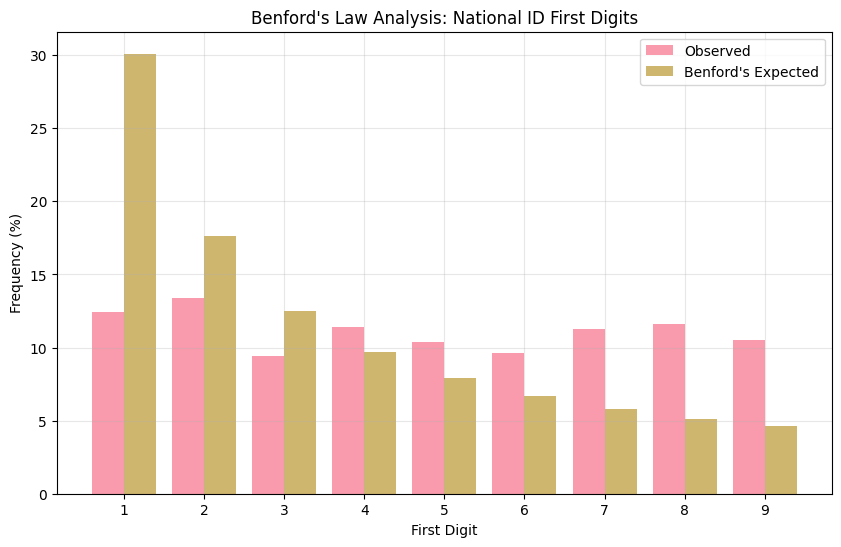

In [ ]:
# Phase 2: Statistical Analysis - Benford's Law
print("\n=== PHASE 2: BENFORD'S LAW ANALYSIS ===")

# Benford's Law expected probabilities
benford_expected = np.array([30.1, 17.6, 12.5, 9.7, 7.9, 6.7, 5.8, 5.1, 4.6]) / 100

# Observed first digit distribution
first_digit_counts = df_clean['National_ID_FirstDigit'].value_counts().sort_index()
observed_frequencies = first_digit_counts.values / len(df_clean)

# Chi-square test for Benford's Law
expected_counts = benford_expected * len(df_clean)
observed_counts = first_digit_counts.values

chi2_stat, p_value = stats.chisquare(observed_counts, expected_counts)

print("Benford's Law Analysis for National ID First Digits:")
print("Digit\tObserved\tExpected\tDifference")
for i in range(9):
    digit = i + 1
    obs_pct = observed_frequencies[i] * 100
    exp_pct = benford_expected[i] * 100
    diff = obs_pct - exp_pct
    print(f"{digit}\t{obs_pct:.1f}%\t\t{exp_pct:.1f}%\t\t{diff:+.1f}%")

print(f"\nChi-square statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.2e}")
print(f"Critical value (α=0.05): 15.51")
print(f"Benford's Law compliance: {'PASS' if chi2_stat < 15.51 else 'FAIL'}")

# Visualization
plt.figure(figsize=(10, 6))
digits = np.arange(1, 10)
plt.bar(digits - 0.2, observed_frequencies * 100, 0.4, label='Observed', alpha=0.7)
plt.bar(digits + 0.2, benford_expected * 100, 0.4, label="Benford's Expected", alpha=0.7)
plt.xlabel('First Digit')
plt.ylabel('Frequency (%)')
plt.title("Benford's Law Analysis: National ID First Digits")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(digits)
plt.show()


Demographic Analysis and Visualizations


=== PHASE 2: DEMOGRAPHIC ANALYSIS ===


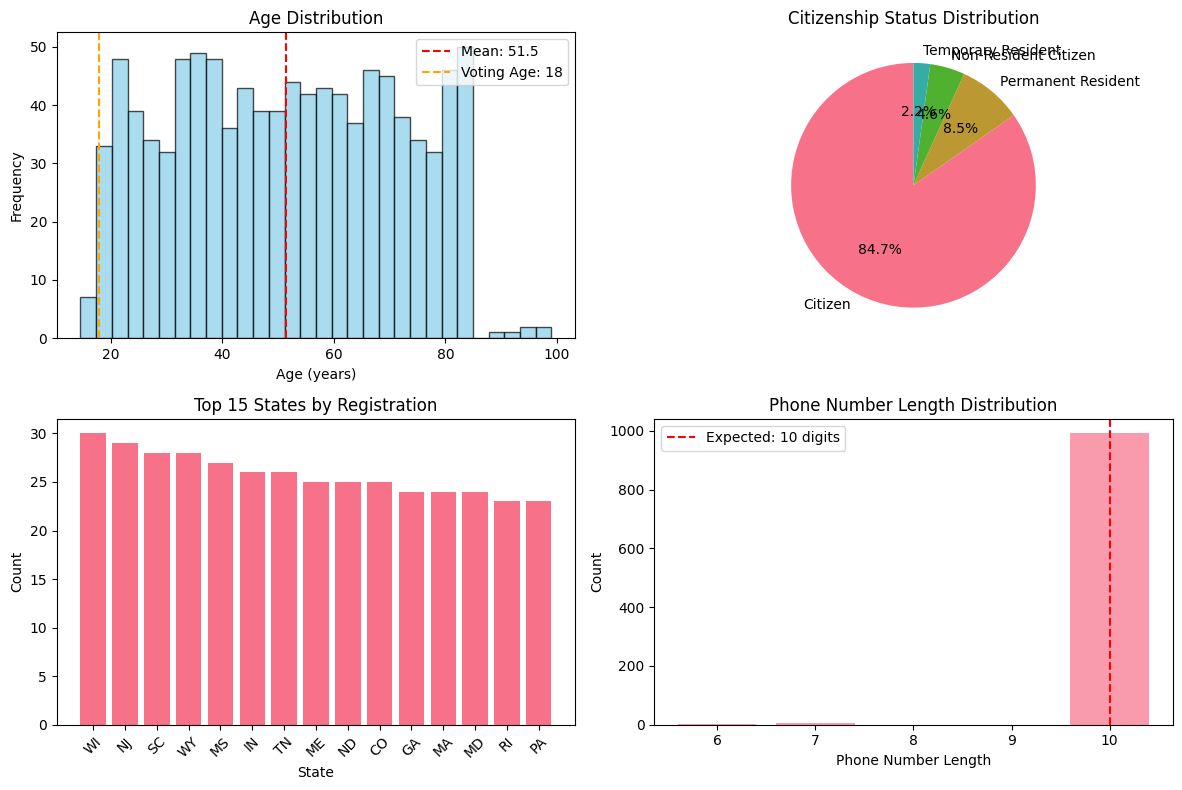


Age statistics by Citizenship Status:
                      count   mean    std   min   max
Citizenship_Status                                   
Citizen                 847  51.37  19.71  14.6  99.0
Non-Resident Citizen     46  48.35  20.72  18.6  90.6
Permanent Resident       85  54.10  19.46  18.3  84.8
Temporary Resident       22  52.20  22.88  18.6  82.1


In [ ]:
# Phase 2: Demographic Analysis and Visualizations
print("\n=== PHASE 2: DEMOGRAPHIC ANALYSIS ===")

# Age distribution histogram
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(df_clean['Age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.axvline(df_clean['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["Age"].mean():.1f}')
plt.axvline(18, color='orange', linestyle='--', label='Voting Age: 18')
plt.legend()

# Citizenship status distribution
plt.subplot(2, 2, 2)
citizenship_counts = df_clean['Citizenship_Status'].value_counts()
plt.pie(citizenship_counts.values, labels=citizenship_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Citizenship Status Distribution')

# State distribution (top 15)
plt.subplot(2, 2, 3)
state_counts = df_clean['State'].value_counts().head(15)
plt.bar(state_counts.index, state_counts.values)
plt.xlabel('State')
plt.ylabel('Count')
plt.title('Top 15 States by Registration')
plt.xticks(rotation=45)

# Phone length distribution
plt.subplot(2, 2, 4)
phone_length_counts = df_clean['Phone_Length'].value_counts().sort_index()
plt.bar(phone_length_counts.index, phone_length_counts.values, alpha=0.7)
plt.xlabel('Phone Number Length')
plt.ylabel('Count')
plt.title('Phone Number Length Distribution')
plt.axvline(10, color='red', linestyle='--', label='Expected: 10 digits')
plt.legend()

plt.tight_layout()
plt.show()

# Summary statistics by citizenship status
print("\nAge statistics by Citizenship Status:")
age_by_citizenship = df_clean.groupby('Citizenship_Status')['Age'].agg(['count', 'mean', 'std', 'min', 'max'])
print(age_by_citizenship.round(2))


Hypothesis Testing

In [ ]:
# Phase 2: Hypothesis Testing
print("\n=== PHASE 2: HYPOTHESIS TESTING ===")

# H1: Test if citizens and non-citizens have different age distributions
citizens = df_clean[df_clean['Citizenship_Status'] == 'Citizen']['Age'].dropna()
non_citizens = df_clean[df_clean['Citizenship_Status'] != 'Citizen']['Age'].dropna()

# T-test for age difference
t_stat, t_p_value = ttest_ind(citizens, non_citizens)
print("H1: Citizens vs Non-Citizens Age Distribution")
print(f"Citizens mean age: {citizens.mean():.2f} ± {citizens.std():.2f}")
print(f"Non-citizens mean age: {non_citizens.mean():.2f} ± {non_citizens.std():.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {t_p_value:.3f}")
print(f"Significant difference: {'Yes' if t_p_value < 0.05 else 'No'}")

# H2: Test association between citizenship status and address mismatch
contingency_table = pd.crosstab(df_clean['Citizenship_Status'], df_clean['Address_Mismatch'])
chi2_citizenship, p_citizenship, dof, expected = chi2_contingency(contingency_table)

print(f"\nH2: Citizenship Status vs Address Mismatch Association")
print("Contingency Table:")
print(contingency_table)
print(f"Chi-square: {chi2_citizenship:.3f}")
print(f"P-value: {p_citizenship:.3f}")
print(f"Significant association: {'Yes' if p_citizenship < 0.05 else 'No'}")

# H3: Test if age follows normal distribution
shapiro_stat, shapiro_p = stats.shapiro(df_clean['Age'].dropna()[:5000])  # Limited sample for Shapiro-Wilk
print(f"\nH3: Age Normality Test (Shapiro-Wilk)")
print(f"Statistic: {shapiro_stat:.3f}")
print(f"P-value: {shapiro_p:.3e}")
print(f"Age follows normal distribution: {'Yes' if shapiro_p > 0.05 else 'No'}")

# H4: Z-test for proportion of duplicates
duplicate_proportion = df_clean['National_ID'].duplicated().mean()
expected_duplicate_rate = 0.01  # 1% expected
n = len(df_clean)
z_stat = (duplicate_proportion - expected_duplicate_rate) / np.sqrt(expected_duplicate_rate * (1 - expected_duplicate_rate) / n)
z_p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"\nH4: Duplicate Rate Test (Z-test)")
print(f"Observed duplicate rate: {duplicate_proportion:.3f}")
print(f"Expected duplicate rate: {expected_duplicate_rate:.3f}")
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {z_p_value:.3f}")
print(f"Significantly different from expected: {'Yes' if z_p_value < 0.05 else 'No'}")



=== PHASE 2: HYPOTHESIS TESTING ===
H1: Citizens vs Non-Citizens Age Distribution
Citizens mean age: 51.37 ± 19.71
Non-citizens mean age: 52.10 ± 20.38
T-statistic: -0.421
P-value: 0.674
Significant difference: No

H2: Citizenship Status vs Address Mismatch Association
Contingency Table:
Address_Mismatch      False  True 
Citizenship_Status                
Citizen                 547    300
Non-Resident Citizen     26     20
Permanent Resident       51     34
Temporary Resident       11     11
Chi-square: 3.573
P-value: 0.311
Significant association: No

H3: Age Normality Test (Shapiro-Wilk)
Statistic: 0.963
P-value: 2.406e-15
Age follows normal distribution: No

H4: Duplicate Rate Test (Z-test)
Observed duplicate rate: 0.004
Expected duplicate rate: 0.010
Z-statistic: -1.907
P-value: 0.057
Significantly different from expected: No


Regression Analysis


=== PHASE 2: REGRESSION ANALYSIS ===
Regression 1: Age ~ Citizenship Status
Coefficient: 0.693
Intercept: 51.285
R-squared: 0.001

Regression 2: Age ~ Address Mismatch
Coefficient: -0.259
Intercept: 51.575
R-squared: 0.000

Multiple Regression: Age ~ Citizenship + Address Mismatch + Phone Length
Coefficients: [ 0.71501146 -0.37946332 -1.65269111]
Feature names: ['Citizenship', 'Address_Mismatch', 'Phone_Length']
Intercept: 67.894
R-squared: 0.001


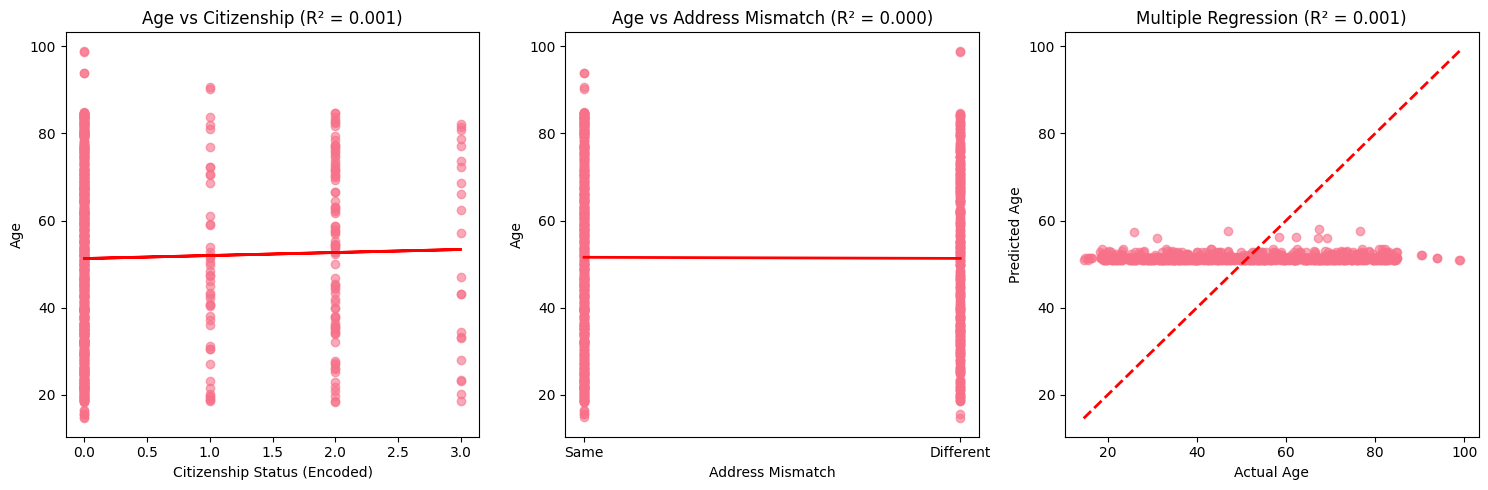

In [ ]:
# Phase 2: Regression Analysis
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

print("\n=== PHASE 2: REGRESSION ANALYSIS ===")

# Prepare data for regression
df_regression = df_clean.dropna(subset=['Age', 'Citizenship_Status'])

# Encode categorical variables
le = LabelEncoder()
df_regression['Citizenship_Encoded'] = le.fit_transform(df_regression['Citizenship_Status'])
df_regression['State_Encoded'] = le.fit_transform(df_regression['State'].fillna('Unknown'))

# Regression 1: Age ~ Citizenship Status
X1 = df_regression[['Citizenship_Encoded']].values
y1 = df_regression['Age'].values

model1 = LinearRegression()
model1.fit(X1, y1)
y1_pred = model1.predict(X1)
r2_1 = r2_score(y1, y1_pred)

print("Regression 1: Age ~ Citizenship Status")
print(f"Coefficient: {model1.coef_[0]:.3f}")
print(f"Intercept: {model1.intercept_:.3f}")
print(f"R-squared: {r2_1:.3f}")

# Regression 2: Age ~ Address Mismatch
X2 = df_regression['Address_Mismatch'].astype(int).values.reshape(-1, 1)
y2 = df_regression['Age'].values

model2 = LinearRegression()
model2.fit(X2, y2)
y2_pred = model2.predict(X2)
r2_2 = r2_score(y2, y2_pred)

print(f"\nRegression 2: Age ~ Address Mismatch")
print(f"Coefficient: {model2.coef_[0]:.3f}")
print(f"Intercept: {model2.intercept_:.3f}")
print(f"R-squared: {r2_2:.3f}")

# Multiple regression: Age ~ Citizenship + Address Mismatch + Phone Length
X3 = df_regression[['Citizenship_Encoded', 'Address_Mismatch', 'Phone_Length']].astype(float)
y3 = df_regression['Age'].values

model3 = LinearRegression()
model3.fit(X3, y3)
y3_pred = model3.predict(X3)
r2_3 = r2_score(y3, y3_pred)

print(f"\nMultiple Regression: Age ~ Citizenship + Address Mismatch + Phone Length")
print(f"Coefficients: {model3.coef_}")
print(f"Feature names: ['Citizenship', 'Address_Mismatch', 'Phone_Length']")
print(f"Intercept: {model3.intercept_:.3f}")
print(f"R-squared: {r2_3:.3f}")

# Visualization of regression results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df_regression['Citizenship_Encoded'], df_regression['Age'], alpha=0.6)
plt.plot(df_regression['Citizenship_Encoded'], y1_pred, color='red', linewidth=2)
plt.xlabel('Citizenship Status (Encoded)')
plt.ylabel('Age')
plt.title(f'Age vs Citizenship (R² = {r2_1:.3f})')

plt.subplot(1, 3, 2)
plt.scatter(df_regression['Address_Mismatch'].astype(int), df_regression['Age'], alpha=0.6)
plt.plot([0, 1], model2.predict([[0], [1]]), color='red', linewidth=2)
plt.xlabel('Address Mismatch')
plt.ylabel('Age')
plt.title(f'Age vs Address Mismatch (R² = {r2_2:.3f})')
plt.xticks([0, 1], ['Same', 'Different'])

plt.subplot(1, 3, 3)
plt.scatter(y3, y3_pred, alpha=0.6)
plt.plot([y3.min(), y3.max()], [y3.min(), y3.max()], 'r--', linewidth=2)
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title(f'Multiple Regression (R² = {r2_3:.3f})')

plt.tight_layout()
plt.show()


Fraud Risk Scoring Model


=== PHASE 2: FRAUD RISK SCORING MODEL ===
Fraud Risk Distribution:
Risk_Category
No Risk        501
Low Risk       462
Medium Risk     35
High Risk        2
Name: count, dtype: int64

High/Critical Risk Records: 2

Top 10 Highest Risk Records:
     National_ID     Name   Surname   Age    Citizenship_Status  \
50     123456789    Kevin      Pope  40.4  Non-Resident Citizen   
150    234567890    Mario  Thompson  66.5    Permanent Resident   
250    345678901      Amy      Lowe  67.5               Citizen   
550    123456789     Mary       Lee  45.6               Citizen   
203    443080569     Jill      Cook  25.9    Permanent Resident   
350    456789012   Donald   Edwards  45.8               Citizen   
377    787554766     John     Burke  98.7               Citizen   
553    950174327   Rachel   Stewart  15.5               Citizen   
605    743855523    Emily      Gray  14.6               Citizen   
650    234567890  Melissa   Parsons  46.7               Citizen   

     Fraud_Risk_S

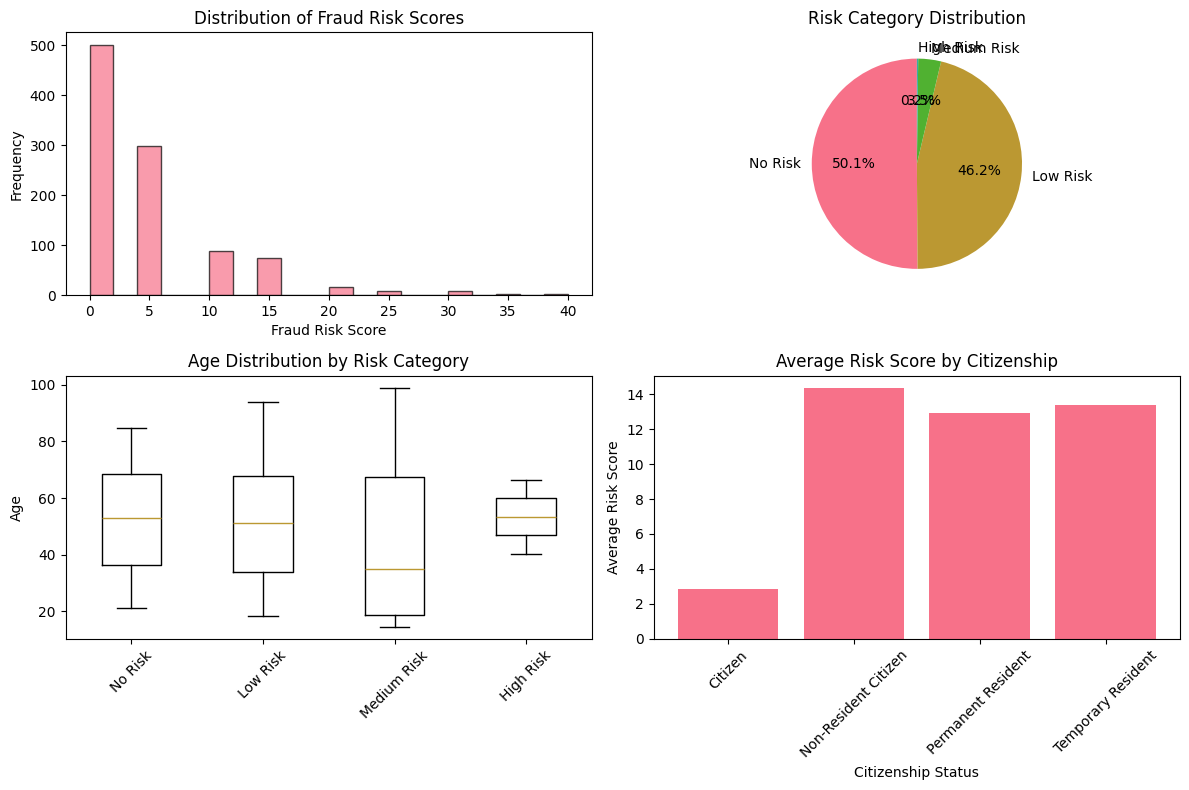

In [ ]:
# Phase 2: Fraud Risk Scoring Model
print("\n=== PHASE 2: FRAUD RISK SCORING MODEL ===")

def calculate_fraud_risk_score(row):
    """Calculate fraud risk score based on multiple factors"""
    score = 0

    # Age-based risk (higher risk for extreme ages)
    if row['Age'] < 18:
        score += 25  # Underage
    elif row['Age'] > 90:
        score += 15  # Very elderly
    elif row['Age'] < 21 or row['Age'] > 85:
        score += 5   # Borderline ages

    # Duplicate National ID
    if row['National_ID'] in df_clean[df_clean['National_ID'].duplicated(keep=False)]['National_ID'].values:
        score += 30

    # Email issues
    if row['Email_Missing']:
        score += 10
    elif not row['Email_Valid']:
        score += 15

    # Phone issues
    if row['Phone_Length'] != 10:
        score += 15

    # Citizenship status risk
    if row['Citizenship_Status'] != 'Citizen':
        score += 10

    # Address mismatch (lower risk)
    if row['Address_Mismatch']:
        score += 5

    return min(score, 100)  # Cap at 100

# Calculate risk scores
df_clean['Fraud_Risk_Score'] = df_clean.apply(calculate_fraud_risk_score, axis=1)

# Risk categories
def risk_category(score):
    if score == 0:
        return 'No Risk'
    elif score <= 15:
        return 'Low Risk'
    elif score <= 35:
        return 'Medium Risk'
    elif score <= 60:
        return 'High Risk'
    else:
        return 'Critical Risk'

df_clean['Risk_Category'] = df_clean['Fraud_Risk_Score'].apply(risk_category)

# Risk distribution
risk_dist = df_clean['Risk_Category'].value_counts()
print("Fraud Risk Distribution:")
print(risk_dist)
print(f"\nHigh/Critical Risk Records: {risk_dist.get('High Risk', 0) + risk_dist.get('Critical Risk', 0)}")

# Top 10 highest risk records
high_risk_records = df_clean.nlargest(10, 'Fraud_Risk_Score')
print(f"\nTop 10 Highest Risk Records:")
print(high_risk_records[['National_ID', 'Name', 'Surname', 'Age', 'Citizenship_Status', 'Fraud_Risk_Score', 'Risk_Category']])

# Visualization of risk scores
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(df_clean['Fraud_Risk_Score'], bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Fraud Risk Score')
plt.ylabel('Frequency')
plt.title('Distribution of Fraud Risk Scores')

plt.subplot(2, 2, 2)
risk_counts = df_clean['Risk_Category'].value_counts()
plt.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Risk Category Distribution')

plt.subplot(2, 2, 3)
plt.boxplot([df_clean[df_clean['Risk_Category'] == cat]['Age'].dropna() for cat in risk_counts.index])
plt.xticks(range(1, len(risk_counts) + 1), risk_counts.index, rotation=45)
plt.ylabel('Age')
plt.title('Age Distribution by Risk Category')

plt.subplot(2, 2, 4)
citizenship_risk = df_clean.groupby('Citizenship_Status')['Fraud_Risk_Score'].mean()
plt.bar(citizenship_risk.index, citizenship_risk.values)
plt.xlabel('Citizenship Status')
plt.ylabel('Average Risk Score')
plt.title('Average Risk Score by Citizenship')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Advanced Forensic Analysis 1: Clustering and Anomaly Detection


=== ADVANCED ANALYSIS 1: CLUSTERING & ANOMALY DETECTION ===
DBSCAN found 2 clusters
Outliers identified by DBSCAN: 28
Anomalies identified by Isolation Forest: 100
PCA Explained Variance Ratio: [0.21720342 0.20662414]


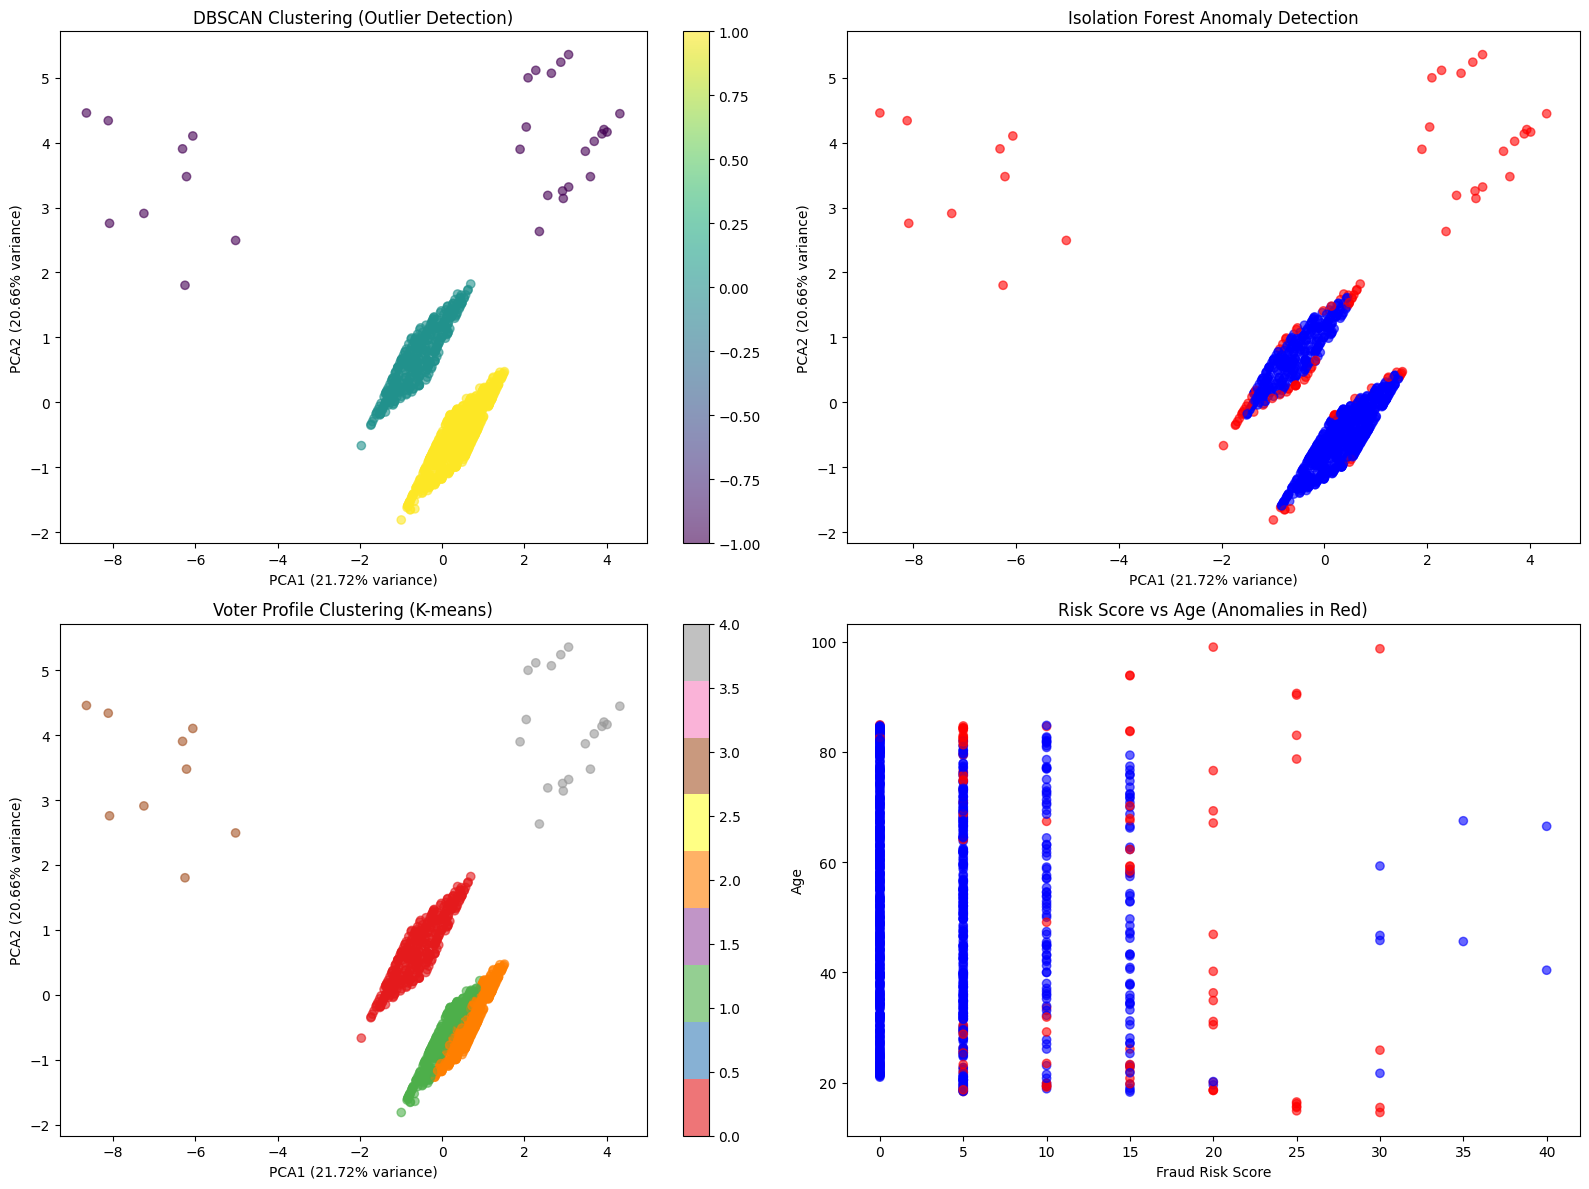


Voter Profile Characteristics:

Profile 0 (n=352):
  Average Age: 51.4
  Most Common Citizenship: Citizen
  Average Risk Score: 7.3
  Address Mismatch Rate: 100.00%

Profile 1 (n=320):
  Average Age: 49.0
  Most Common Citizenship: Citizen
  Average Risk Score: 2.7
  Address Mismatch Rate: 0.00%

Profile 2 (n=300):
  Average Age: 54.4
  Most Common Citizenship: Citizen
  Average Risk Score: 1.7
  Address Mismatch Rate: 0.00%

Profile 3 (n=9):
  Average Age: 56.1
  Most Common Citizenship: Citizen
  Average Risk Score: 19.4
  Address Mismatch Rate: 66.67%

Profile 4 (n=19):
  Average Age: 47.0
  Most Common Citizenship: Citizen
  Average Risk Score: 16.6
  Address Mismatch Rate: 36.84%


In [ ]:
# Advanced Analysis 1: Clustering and Anomaly Detection
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("\n=== ADVANCED ANALYSIS 1: CLUSTERING & ANOMALY DETECTION ===")

# Prepare numerical data for clustering
numerical_features = ['Age', 'Phone_Length', 'National_ID_FirstDigit',
                     'Address_Mismatch', 'Email_Valid']
X_cluster = df_clean[numerical_features].copy()
X_cluster['Address_Mismatch'] = X_cluster['Address_Mismatch'].astype(int)
X_cluster['Email_Valid'] = X_cluster['Email_Valid'].astype(int)

# Handle missing values
X_cluster = X_cluster.fillna(X_cluster.mean())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# DBSCAN Clustering for outlier detection
dbscan = DBSCAN(eps=0.8, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)
df_clean['DBSCAN_Cluster'] = clusters

# Isolation Forest for anomaly detection
iso_forest = IsolationForest(contamination=0.1, random_state=42)
anomaly_scores = iso_forest.fit_predict(X_scaled)
df_clean['Isolation_Anomaly'] = anomaly_scores

print(f"DBSCAN found {len(set(clusters)) - (1 if -1 in clusters else 0)} clusters")
print(f"Outliers identified by DBSCAN: {(clusters == -1).sum()}")
print(f"Anomalies identified by Isolation Forest: {(anomaly_scores == -1).sum()}")

# K-means clustering for voter profiling
kmeans = KMeans(n_clusters=5, random_state=42)
voter_profiles = kmeans.fit_predict(X_scaled)
df_clean['Voter_Profile'] = voter_profiles

# PCA for dimensionality reduction and visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clean['PCA1'] = X_pca[:, 0]
df_clean['PCA2'] = X_pca[:, 1]

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# DBSCAN Clustering
scatter1 = axes[0,0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
axes[0,0].set_title('DBSCAN Clustering (Outlier Detection)')
axes[0,0].set_xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0,0].set_ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter1, ax=axes[0,0])

# Isolation Forest Anomalies
colors = ['red' if x == -1 else 'blue' for x in anomaly_scores]
axes[0,1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6)
axes[0,1].set_title('Isolation Forest Anomaly Detection')
axes[0,1].set_xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0,1].set_ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

# Voter Profiles
scatter3 = axes[1,0].scatter(X_pca[:, 0], X_pca[:, 1], c=voter_profiles, cmap='Set1', alpha=0.6)
axes[1,0].set_title('Voter Profile Clustering (K-means)')
axes[1,0].set_xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[1,0].set_ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter3, ax=axes[1,0])

# Risk Score vs Anomaly Detection
axes[1,1].scatter(df_clean['Fraud_Risk_Score'], df_clean['Age'],
                 c=['red' if x == -1 else 'blue' for x in anomaly_scores], alpha=0.6)
axes[1,1].set_xlabel('Fraud Risk Score')
axes[1,1].set_ylabel('Age')
axes[1,1].set_title('Risk Score vs Age (Anomalies in Red)')

plt.tight_layout()
plt.show()

# Profile characteristics
print("\nVoter Profile Characteristics:")
for profile in range(5):
    profile_data = df_clean[df_clean['Voter_Profile'] == profile]
    print(f"\nProfile {profile} (n={len(profile_data)}):")
    print(f"  Average Age: {profile_data['Age'].mean():.1f}")
    print(f"  Most Common Citizenship: {profile_data['Citizenship_Status'].mode().iloc[0]}")
    print(f"  Average Risk Score: {profile_data['Fraud_Risk_Score'].mean():.1f}")
    print(f"  Address Mismatch Rate: {profile_data['Address_Mismatch'].mean():.2%}")


Advanced Analysis 2: Time-based Patterns and Digital Forensics


=== ADVANCED ANALYSIS 2: TIME-BASED & DIGITAL FORENSICS ===
Years with suspiciously high registration counts:
Birth_Year
1943    21
1993    22
Name: count, dtype: int64

Date Heaping Analysis:
Births on 1st, 15th, 30th, 31st: 113
Expected (uniform): 129.0
Heaping Ratio: 0.88 (>1.5 suggests fabrication)

Top Email Domains:
Email_Domain
example.net    173
example.org    171
hotmail.com    168
example.com    159
yahoo.com      155
gmail.com      155
Name: count, dtype: int64

Top Area Codes:
Area_Code
343    6
379    6
252    5
860    5
816    5
732    5
302    5
705    5
483    4
446    4
Name: count, dtype: int64


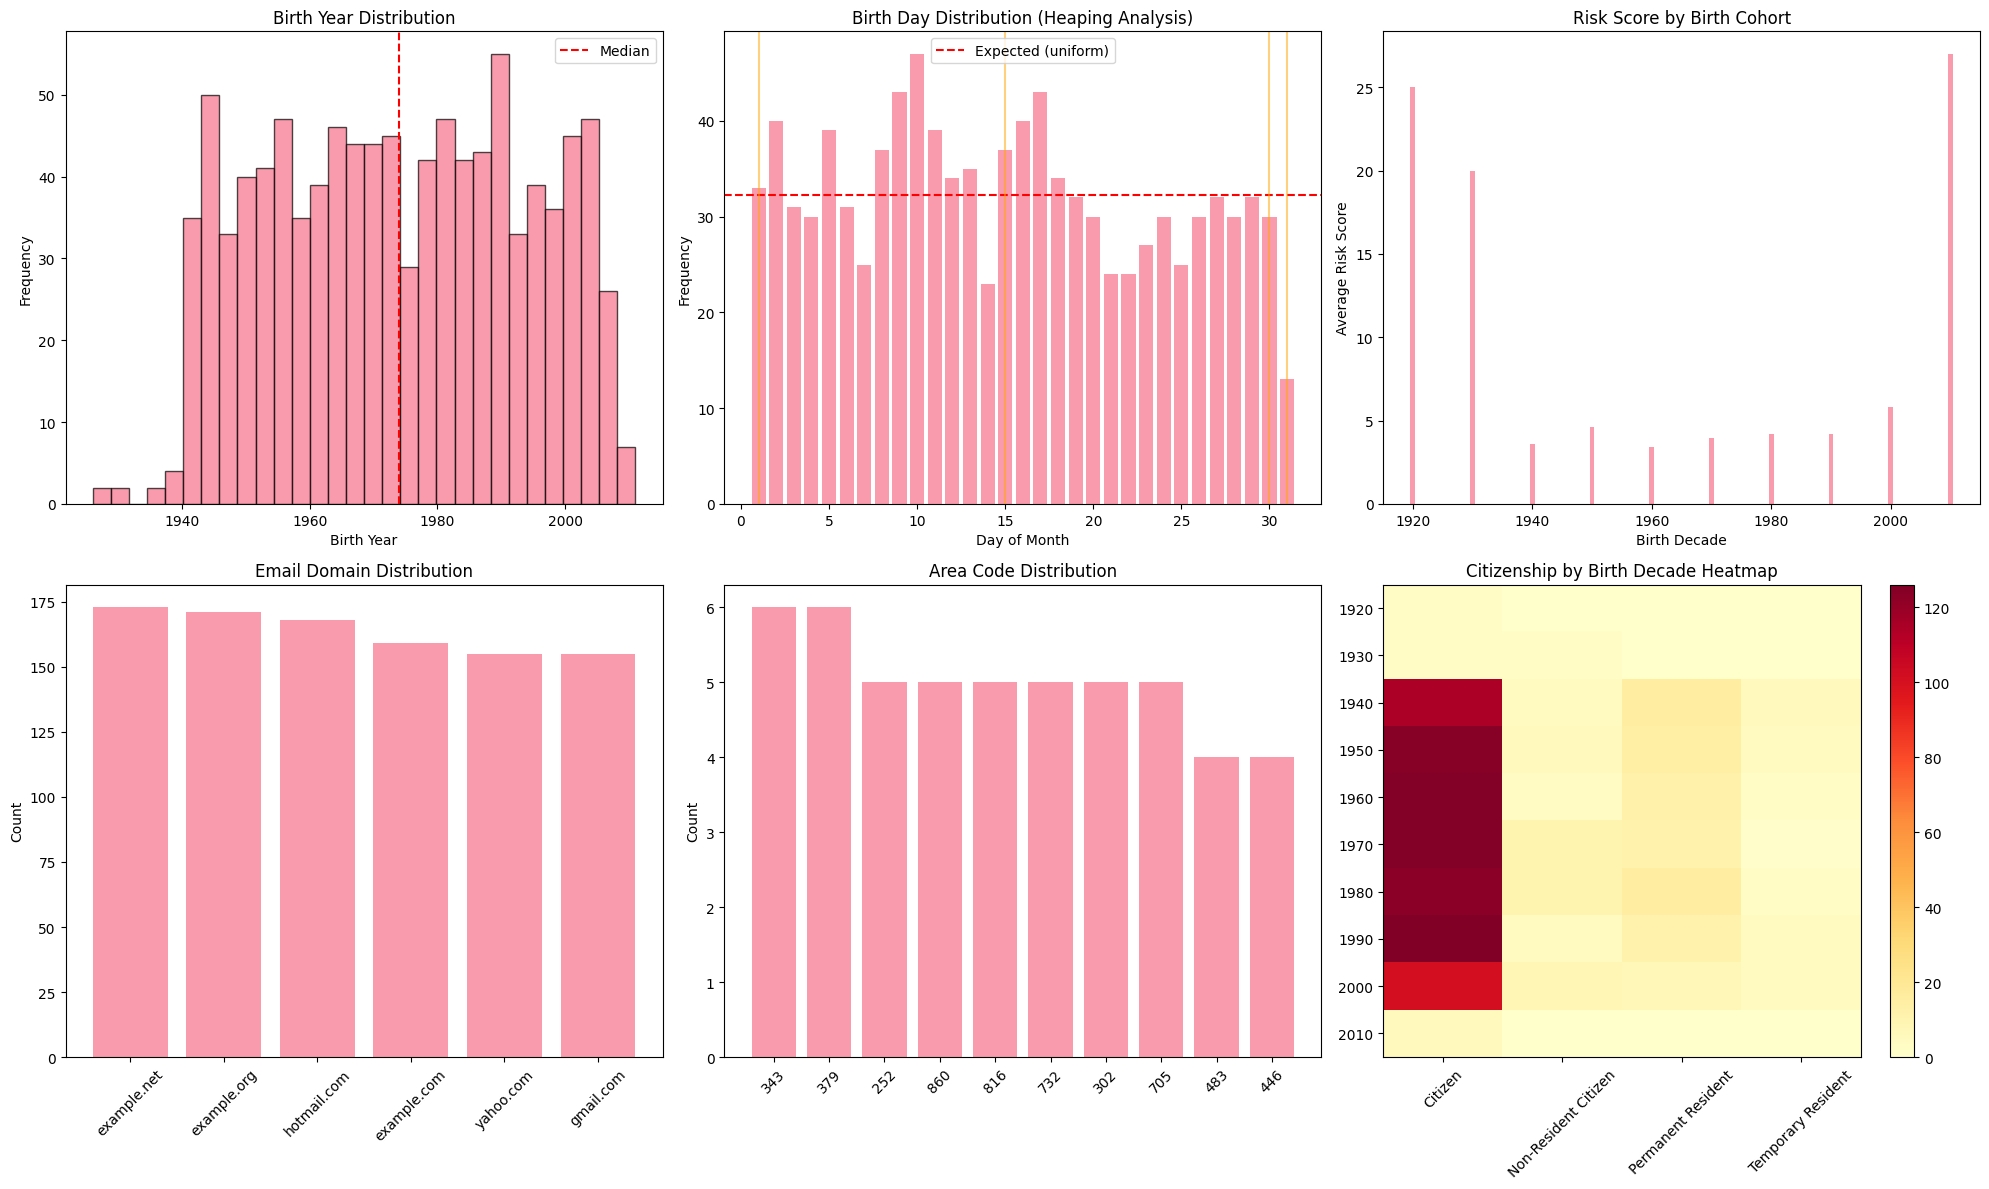

In [ ]:
# Advanced Analysis 2: Time-based Patterns and Digital Forensics
print("\n=== ADVANCED ANALYSIS 2: TIME-BASED & DIGITAL FORENSICS ===")

# Birth year analysis for cohort patterns
df_clean['Birth_Year'] = df_clean['DOB_parsed'].dt.year
df_clean['Birth_Decade'] = (df_clean['Birth_Year'] // 10) * 10

# Analyze birth year distributions for anomalies
birth_year_counts = df_clean['Birth_Year'].value_counts().sort_index()

# Check for suspicious patterns in birth years
suspicious_years = birth_year_counts[birth_year_counts > birth_year_counts.quantile(0.95)]
print(f"Years with suspiciously high registration counts:")
print(suspicious_years)

# Day-of-month analysis for fabricated dates
df_clean['Birth_Day'] = df_clean['DOB_parsed'].dt.day
day_distribution = df_clean['Birth_Day'].value_counts().sort_index()

# Check for heaping on certain days (1st, 15th, etc.)
heaping_days = [1, 15, 30, 31]
heaping_counts = day_distribution[heaping_days].sum()
expected_heaping = len(df_clean) * len(heaping_days) / 31
heaping_ratio = heaping_counts / expected_heaping

print(f"\nDate Heaping Analysis:")
print(f"Births on 1st, 15th, 30th, 31st: {heaping_counts}")
print(f"Expected (uniform): {expected_heaping:.1f}")
print(f"Heaping Ratio: {heaping_ratio:.2f} (>1.5 suggests fabrication)")

# Email domain analysis for patterns
df_clean['Email_Domain'] = df_clean['Email'].str.extract(r'@(.+)$')
domain_counts = df_clean['Email_Domain'].value_counts().head(10)

print(f"\nTop Email Domains:")
print(domain_counts)

# Phone area code analysis
df_clean['Area_Code'] = df_clean['Phone_Digits'].str[:3]
area_code_counts = df_clean['Area_Code'].value_counts().head(10)

print(f"\nTop Area Codes:")
print(area_code_counts)

# Advanced visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Birth year distribution
axes[0,0].hist(df_clean['Birth_Year'].dropna(), bins=30, alpha=0.7, edgecolor='black')
axes[0,0].set_xlabel('Birth Year')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Birth Year Distribution')
axes[0,0].axvline(df_clean['Birth_Year'].median(), color='red', linestyle='--', label='Median')
axes[0,0].legend()

# Birth day heaping
axes[0,1].bar(day_distribution.index, day_distribution.values, alpha=0.7)
axes[0,1].set_xlabel('Day of Month')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Birth Day Distribution (Heaping Analysis)')
axes[0,1].axhline(len(df_clean)/31, color='red', linestyle='--', label='Expected (uniform)')
for day in heaping_days:
    axes[0,1].axvline(day, color='orange', alpha=0.5)
axes[0,1].legend()

# Age cohort risk analysis
cohort_risk = df_clean.groupby('Birth_Decade')['Fraud_Risk_Score'].agg(['mean', 'count'])
axes[0,2].bar(cohort_risk.index, cohort_risk['mean'], alpha=0.7)
axes[0,2].set_xlabel('Birth Decade')
axes[0,2].set_ylabel('Average Risk Score')
axes[0,2].set_title('Risk Score by Birth Cohort')

# Email domain distribution
if len(domain_counts) > 0:
    axes[1,0].bar(range(len(domain_counts)), domain_counts.values, alpha=0.7)
    axes[1,0].set_xticks(range(len(domain_counts)))
    axes[1,0].set_xticklabels(domain_counts.index, rotation=45)
    axes[1,0].set_ylabel('Count')
    axes[1,0].set_title('Email Domain Distribution')

# Area code geographic analysis
if len(area_code_counts) > 0:
    axes[1,1].bar(range(len(area_code_counts)), area_code_counts.values, alpha=0.7)
    axes[1,1].set_xticks(range(len(area_code_counts)))
    axes[1,1].set_xticklabels(area_code_counts.index, rotation=45)
    axes[1,1].set_ylabel('Count')
    axes[1,1].set_title('Area Code Distribution')

# Citizenship vs Birth Decade heatmap
citizenship_decade = pd.crosstab(df_clean['Birth_Decade'], df_clean['Citizenship_Status'])
im = axes[1,2].imshow(citizenship_decade.values, cmap='YlOrRd', aspect='auto')
axes[1,2].set_xticks(range(len(citizenship_decade.columns)))
axes[1,2].set_xticklabels(citizenship_decade.columns, rotation=45)
axes[1,2].set_yticks(range(len(citizenship_decade.index)))
axes[1,2].set_yticklabels(citizenship_decade.index)
axes[1,2].set_title('Citizenship by Birth Decade Heatmap')
plt.colorbar(im, ax=axes[1,2])

plt.tight_layout()
plt.show()


Advanced Analysis 3: Network Analysis and Geographic Patterns


=== ADVANCED ANALYSIS 3: NETWORK & GEOGRAPHIC ANALYSIS ===
Network Analysis Results:
Nodes: 0
Edges: 0
Connected components: 0
Suspicious clusters (>2 connected records): 0

Geographic Clustering Analysis:
Unique streets: 10
Streets with >3 registrations: 10
Most clustered streets:
Street_Name
Oak Ave       123
Cedar Dr      114
Pine Rd       108
Second Ave    103
Main St       102
Name: count, dtype: int64

Top 10 States by Average Risk Score:
       Avg_Age  Age_StdDev  Count  NonCitizen_Rate  Avg_Risk  Mismatch_Rate
State                                                                      
MI      43.527      20.035     11            0.273     8.182          0.636
CA      53.259      20.821     17            0.235     7.059          0.647
MD      54.221      22.184     24            0.208     6.458          0.292
VT      56.773      24.126     15            0.067     6.333          0.400
GA      49.104      19.776     24            0.292     6.042          0.542
DE      53.590    

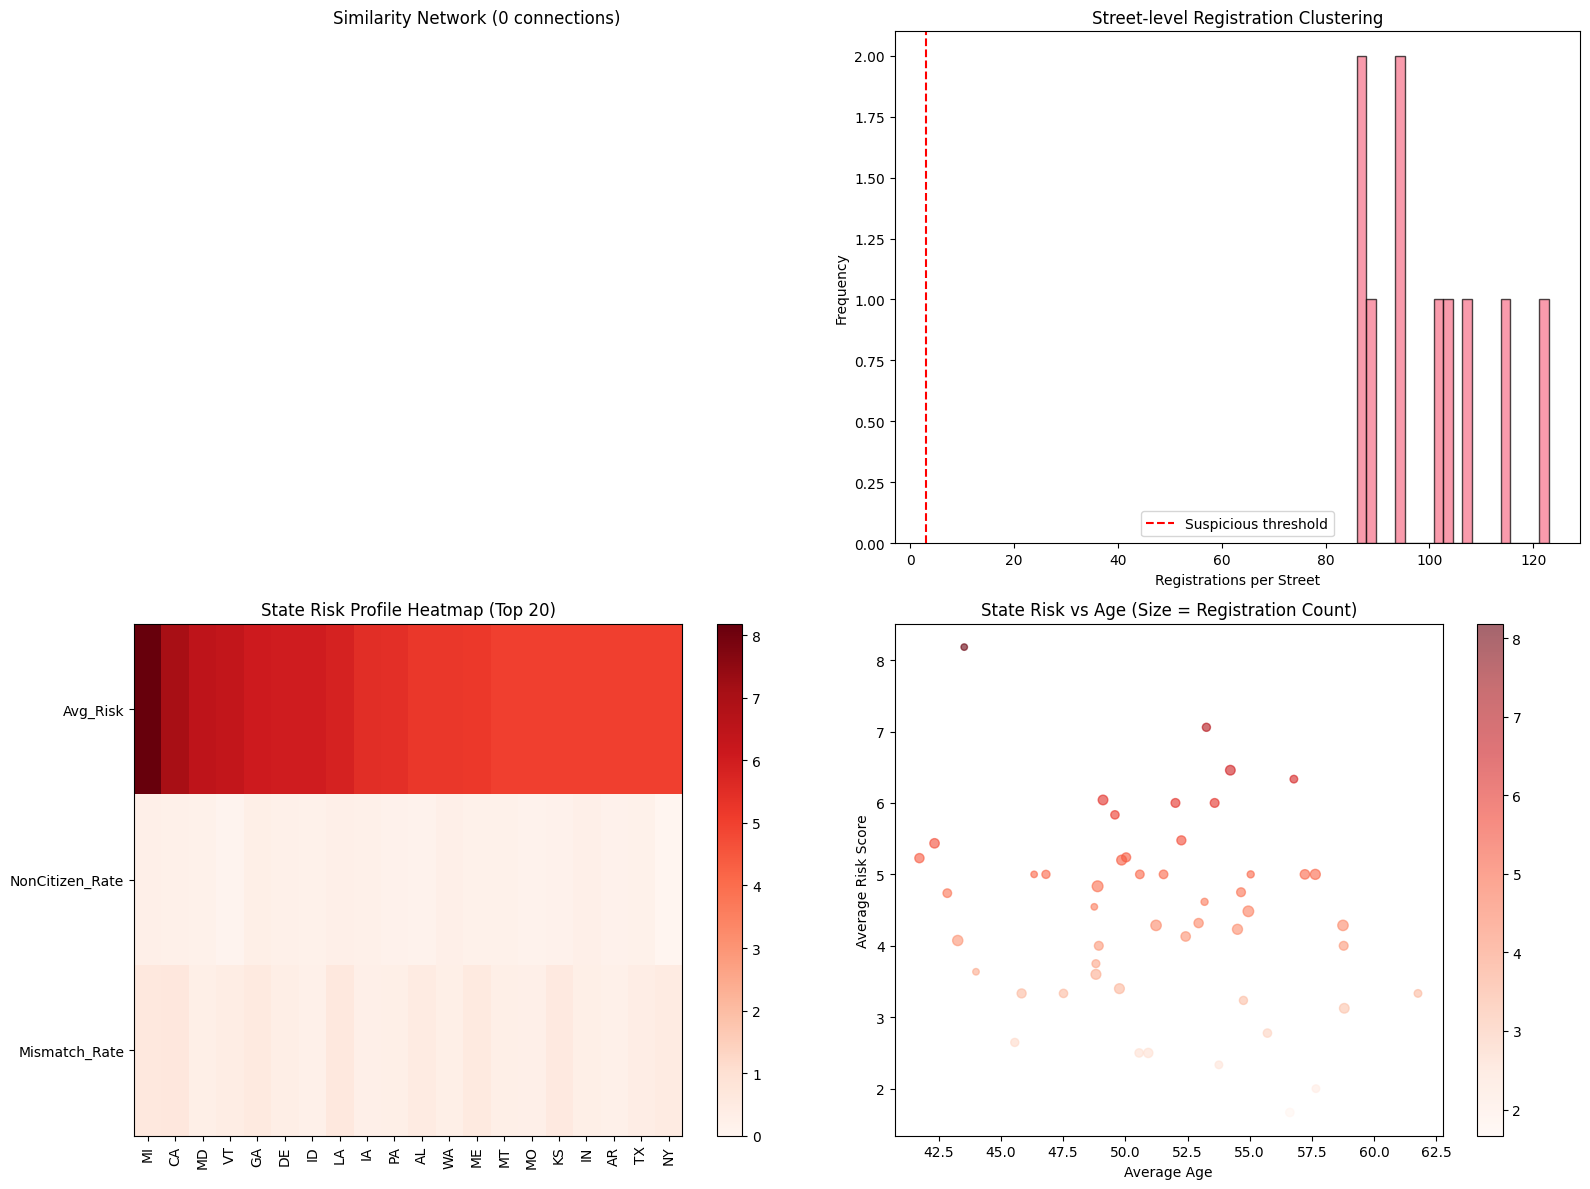

In [ ]:
# Advanced Analysis 3: Network Analysis and Geographic Patterns
import networkx as nx
from collections import Counter

print("\n=== ADVANCED ANALYSIS 3: NETWORK & GEOGRAPHIC ANALYSIS ===")

# Create similarity networks based on shared attributes
def create_similarity_network(df, threshold=0.7):
    """Create network of potentially related records"""
    G = nx.Graph()

    for i, row1 in df.iterrows():
        for j, row2 in df.iterrows():
            if i >= j:
                continue

            similarity_score = 0

            # Same surname
            if row1['Surname'] == row2['Surname']:
                similarity_score += 0.3

            # Similar age (within 5 years)
            if abs(row1['Age'] - row2['Age']) <= 5:
                similarity_score += 0.2

            # Same state
            if row1['State'] == row2['State']:
                similarity_score += 0.2

            # Same area code
            if str(row1['Phone_Digits'])[:3] == str(row2['Phone_Digits'])[:3]:
                similarity_score += 0.3

            if similarity_score >= threshold:
                G.add_edge(i, j, weight=similarity_score)

    return G

# Analyze address patterns for clustering
def analyze_address_clustering(df):
    """Analyze geographic clustering of registrations"""
    # Extract street names
    df['Street_Name'] = df['Residential_Address'].str.extract(r'\d+\s+(.+?),')[0]

    # Count registrations per street
    street_counts = df['Street_Name'].value_counts()
    suspicious_streets = street_counts[street_counts > 3]

    return street_counts, suspicious_streets

# Create similarity network (limited sample for performance)
sample_df = df_clean.sample(min(200, len(df_clean)), random_state=42)
G = create_similarity_network(sample_df)

print(f"Network Analysis Results:")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Connected components: {nx.number_connected_components(G)}")

# Find suspicious clusters
components = list(nx.connected_components(G))
large_components = [comp for comp in components if len(comp) > 2]

print(f"Suspicious clusters (>2 connected records): {len(large_components)}")

# Address clustering analysis
street_counts, suspicious_streets = analyze_address_clustering(df_clean)
print(f"\nGeographic Clustering Analysis:")
print(f"Unique streets: {len(street_counts)}")
print(f"Streets with >3 registrations: {len(suspicious_streets)}")

if len(suspicious_streets) > 0:
    print("Most clustered streets:")
    print(suspicious_streets.head())

# State-level analysis for unusual patterns
state_stats = df_clean.groupby('State').agg({
    'Age': ['mean', 'std', 'count'],
    'Citizenship_Status': lambda x: (x != 'Citizen').mean(),
    'Fraud_Risk_Score': 'mean',
    'Address_Mismatch': 'mean'
}).round(3)

state_stats.columns = ['Avg_Age', 'Age_StdDev', 'Count', 'NonCitizen_Rate', 'Avg_Risk', 'Mismatch_Rate']
state_stats = state_stats.sort_values('Avg_Risk', ascending=False)

print(f"\nTop 10 States by Average Risk Score:")
print(state_stats.head(10))

# Advanced visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Network visualization (if not too large)
if len(G.nodes()) <= 100:
    pos = nx.spring_layout(G, k=0.5, iterations=50)
    nx.draw(G, pos, ax=axes[0,0], node_size=30, node_color='lightblue',
            edge_color='gray', alpha=0.7, with_labels=False)
    axes[0,0].set_title(f'Similarity Network ({G.number_of_edges()} connections)')
else:
    axes[0,0].text(0.5, 0.5, 'Network too large to visualize',
                   ha='center', va='center', transform=axes[0,0].transAxes)
    axes[0,0].set_title('Similarity Network (Too Large)')

# Street clustering histogram
if len(street_counts) > 0:
    axes[0,1].hist(street_counts.values, bins=20, alpha=0.7, edgecolor='black')
    axes[0,1].set_xlabel('Registrations per Street')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].set_title('Street-level Registration Clustering')
    axes[0,1].axvline(3, color='red', linestyle='--', label='Suspicious threshold')
    axes[0,1].legend()

# State risk heatmap (top 20 states)
top_states = state_stats.head(20)
risk_matrix = top_states[['Avg_Risk', 'NonCitizen_Rate', 'Mismatch_Rate']].T
im = axes[1,0].imshow(risk_matrix.values, cmap='Reds', aspect='auto')
axes[1,0].set_xticks(range(len(top_states)))
axes[1,0].set_xticklabels(top_states.index, rotation=90)
axes[1,0].set_yticks(range(len(risk_matrix)))
axes[1,0].set_yticklabels(risk_matrix.index)
axes[1,0].set_title('State Risk Profile Heatmap (Top 20)')
plt.colorbar(im, ax=axes[1,0])

# Age vs State scatter (risk-colored)
state_age_risk = df_clean.groupby('State').agg({
    'Age': 'mean',
    'Fraud_Risk_Score': 'mean',
    'National_ID': 'count'
}).reset_index()

scatter = axes[1,1].scatter(state_age_risk['Age'], state_age_risk['Fraud_Risk_Score'],
                           s=state_age_risk['National_ID']*2, alpha=0.6,
                           c=state_age_risk['Fraud_Risk_Score'], cmap='Reds')
axes[1,1].set_xlabel('Average Age')
axes[1,1].set_ylabel('Average Risk Score')
axes[1,1].set_title('State Risk vs Age (Size = Registration Count)')
plt.colorbar(scatter, ax=axes[1,1])

plt.tight_layout()
plt.show()


Advanced Analysis 4: Machine Learning Classification and Feature Importance


=== ADVANCED ANALYSIS 4: ML CLASSIFICATION ===
Features: ['Age', 'Phone_Length', 'National_ID_FirstDigit', 'Address_Mismatch', 'Email_Valid', 'Email_Missing', 'Birth_Day', 'Birth_Year', 'Citizenship_Encoded']
High risk cases: 112 (11.2%)

Model Performance (Cross-Validation):
Random Forest: 0.986 ± 0.004
Gradient Boosting: 0.981 ± 0.006

Feature Importance Ranking:
                  Feature  RF_Importance  GB_Importance
8     Citizenship_Encoded       0.339650       0.264652
3        Address_Mismatch       0.188244       0.297878
0                     Age       0.124392       0.153778
7              Birth_Year       0.107742       0.063644
4             Email_Valid       0.086115       0.091688
1            Phone_Length       0.076428       0.092950
6               Birth_Day       0.037188       0.002148
2  National_ID_FirstDigit       0.027822       0.003762
5           Email_Missing       0.012419       0.029499

Random Forest Classification Report:
              precision    recall

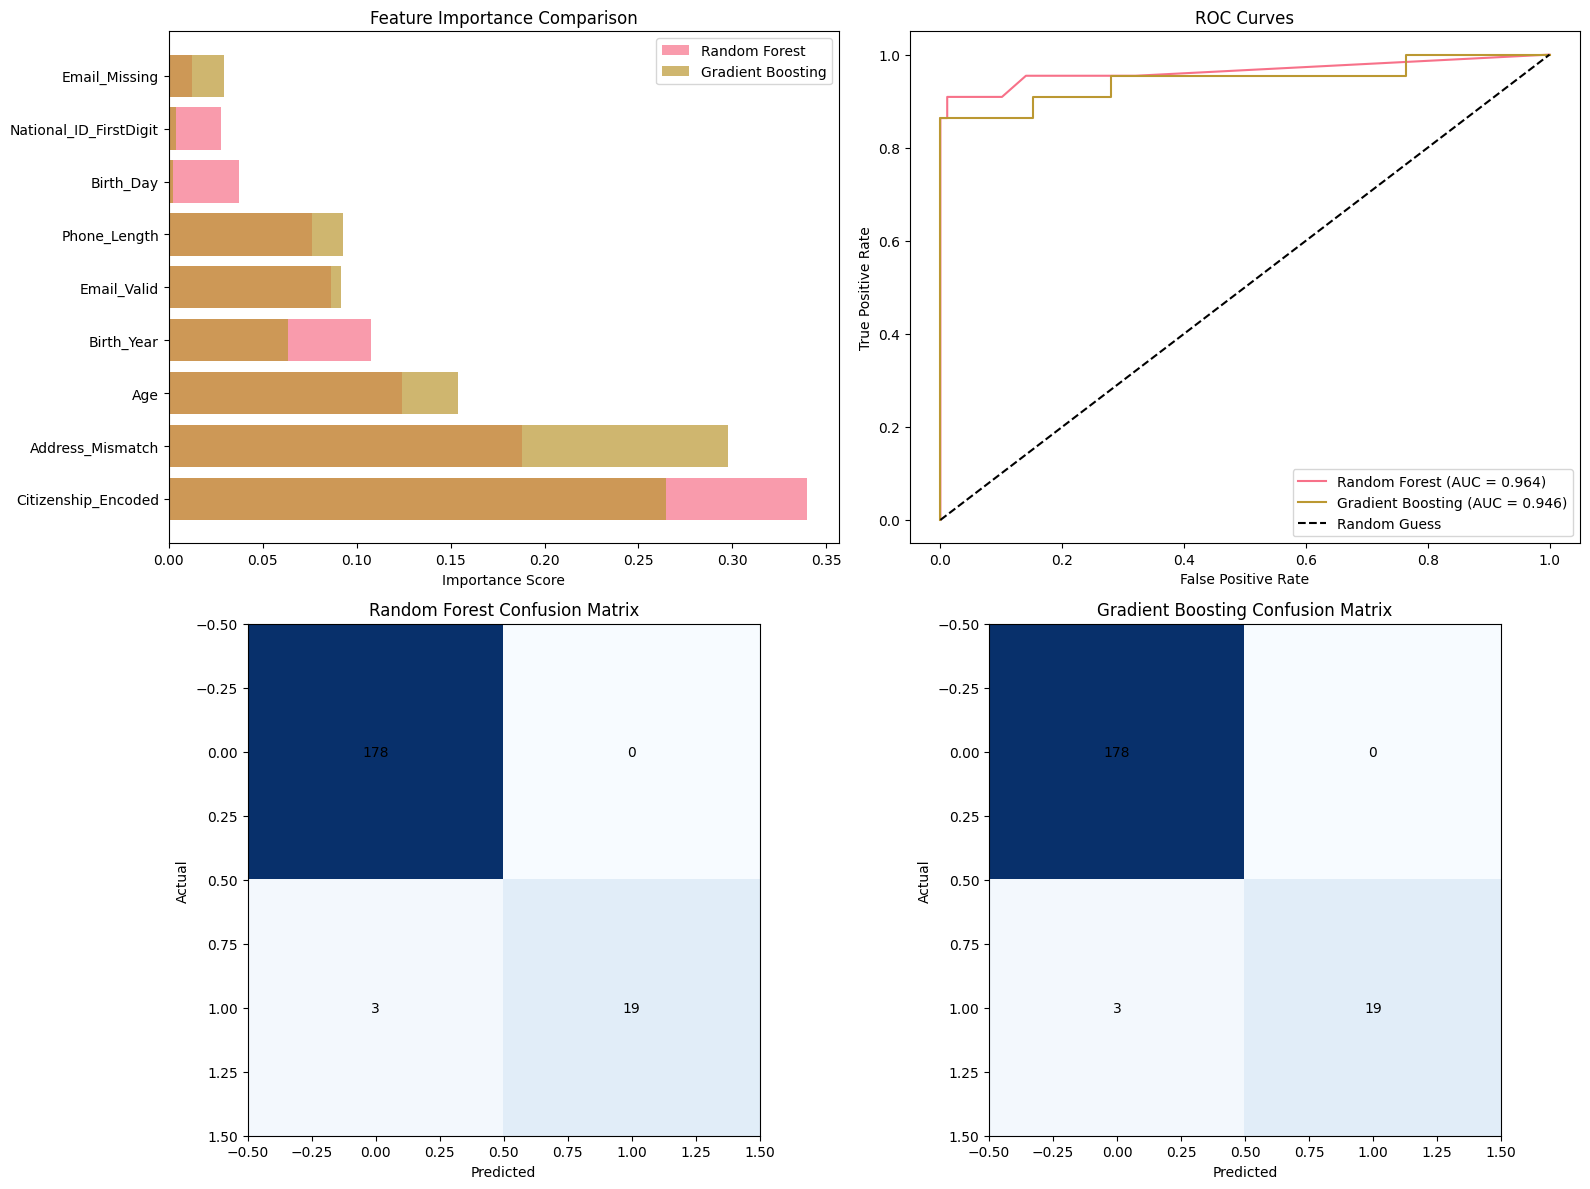


ML Model Risk Predictions:
High risk predictions: 109
Average risk probability: 0.108


In [ ]:
# Advanced Analysis 4: ML Classification and Feature Importance
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

print("\n=== ADVANCED ANALYSIS 4: ML CLASSIFICATION ===")

# Prepare features for ML
feature_columns = ['Age', 'Phone_Length', 'National_ID_FirstDigit', 'Address_Mismatch',
                   'Email_Valid', 'Email_Missing', 'Birth_Day', 'Birth_Year']

X_ml = df_clean[feature_columns].copy()
X_ml['Address_Mismatch'] = X_ml['Address_Mismatch'].astype(int)
X_ml['Email_Valid'] = X_ml['Email_Valid'].astype(int)
X_ml['Email_Missing'] = X_ml['Email_Missing'].astype(int)

# Add citizenship encoding
le_citizenship = LabelEncoder()
X_ml['Citizenship_Encoded'] = le_citizenship.fit_transform(df_clean['Citizenship_Status'])

# Create binary target: High Risk (1) vs Low Risk (0)
y_ml = (df_clean['Fraud_Risk_Score'] > df_clean['Fraud_Risk_Score'].quantile(0.8)).astype(int)

# Handle missing values
X_ml = X_ml.fillna(X_ml.mean())

print(f"Features: {list(X_ml.columns)}")
print(f"High risk cases: {y_ml.sum()} ({y_ml.mean():.1%})")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2,
                                                    random_state=42, stratify=y_ml)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_pred_proba = gb_model.predict_proba(X_test)[:, 1]

# Cross-validation scores
rf_cv_scores = cross_val_score(rf_model, X_ml, y_ml, cv=5)
gb_cv_scores = cross_val_score(gb_model, X_ml, y_ml, cv=5)

print(f"\nModel Performance (Cross-Validation):")
print(f"Random Forest: {rf_cv_scores.mean():.3f} ± {rf_cv_scores.std():.3f}")
print(f"Gradient Boosting: {gb_cv_scores.mean():.3f} ± {gb_cv_scores.std():.3f}")

# Feature importance
rf_importance = pd.DataFrame({
    'Feature': X_ml.columns,
    'RF_Importance': rf_model.feature_importances_,
    'GB_Importance': gb_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print(f"\nFeature Importance Ranking:")
print(rf_importance)

# Model evaluation
print(f"\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print(f"\nGradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Feature importance comparison
axes[0,0].barh(rf_importance['Feature'], rf_importance['RF_Importance'], alpha=0.7, label='Random Forest')
axes[0,0].barh(rf_importance['Feature'], rf_importance['GB_Importance'], alpha=0.7, label='Gradient Boosting')
axes[0,0].set_xlabel('Importance Score')
axes[0,0].set_title('Feature Importance Comparison')
axes[0,0].legend()

# ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_pred_proba)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

axes[0,1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
axes[0,1].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curves')
axes[0,1].legend()

# Confusion matrices
cm_rf = confusion_matrix(y_test, rf_pred)
cm_gb = confusion_matrix(y_test, gb_pred)

im1 = axes[1,0].imshow(cm_rf, cmap='Blues')
axes[1,0].set_title('Random Forest Confusion Matrix')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, cm_rf[i, j], ha='center', va='center')

im2 = axes[1,1].imshow(cm_gb, cmap='Blues')
axes[1,1].set_title('Gradient Boosting Confusion Matrix')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[1,1].text(j, i, cm_gb[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

# Predict risk for all records
df_clean['ML_Risk_Probability'] = rf_model.predict_proba(X_ml)[:, 1]
df_clean['ML_Risk_Prediction'] = rf_model.predict(X_ml)

print(f"\nML Model Risk Predictions:")
print(f"High risk predictions: {df_clean['ML_Risk_Prediction'].sum()}")
print(f"Average risk probability: {df_clean['ML_Risk_Probability'].mean():.3f}")


In [ ]:
Advanced Analysis 5: Comprehensive Forensic Dashboard


=== ADVANCED ANALYSIS 5: FORENSIC DASHBOARD (spaced) ===


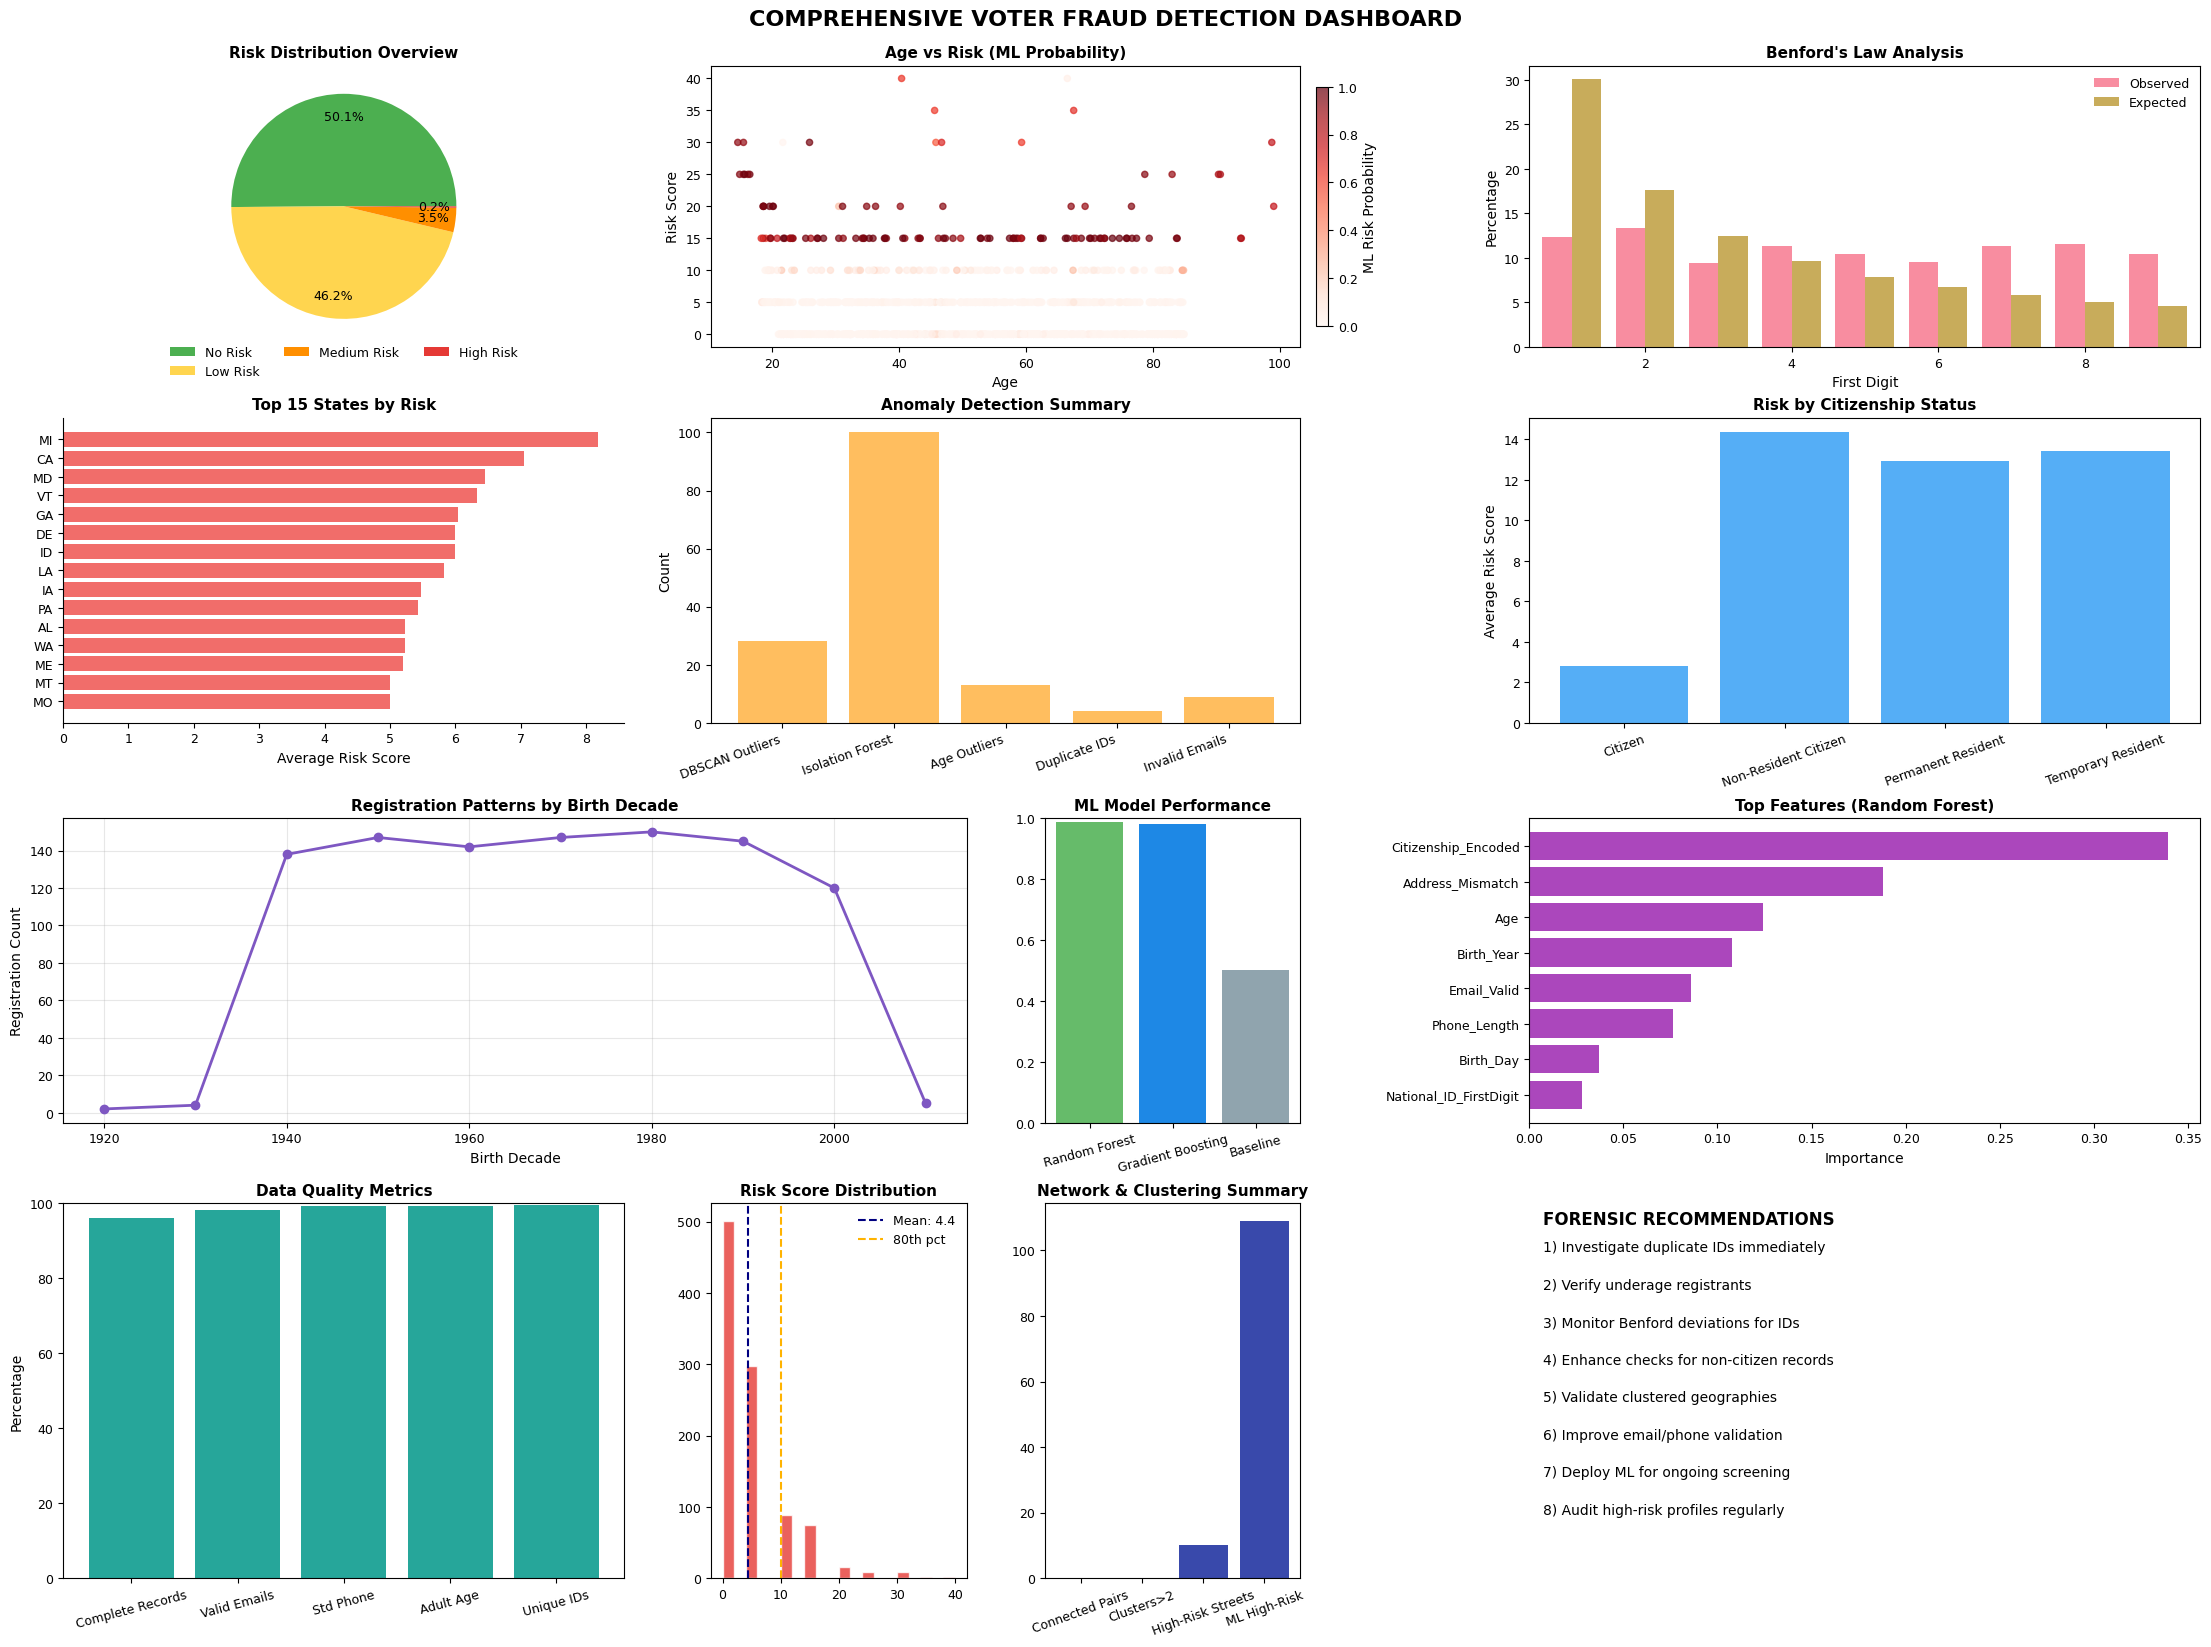

In [ ]:
# ADVANCED ANALYSIS 5: FORENSIC DASHBOARD (non-overlapping layout)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({
    "figure.autolayout": False,          # we'll control with constrained_layout
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

print("\n=== ADVANCED ANALYSIS 5: FORENSIC DASHBOARD (spaced) ===")

# Use constrained_layout to manage spacing
fig = plt.figure(figsize=(22, 16), constrained_layout=True)

# GridSpec with asymmetry: more width for heatmaps/text; taller last row for summaries
gs = fig.add_gridspec(
    nrows=4, ncols=6,  # finer grid to control spans
    width_ratios=[1.2, 1.4, 1.4, 1.4, 1.6, 1.6],
    height_ratios=[1.2, 1.3, 1.3, 1.6]
)

# 1) Risk pie (1x2)
ax1 = fig.add_subplot(gs[0, 0:2])
risk_dist = df_clean['Risk_Category'].value_counts()
colors = ['#4caf50', '#ffd54f', '#ff8f00', '#e53935', '#8e0000'][:len(risk_dist)]
wedges, texts, autotexts = ax1.pie(
    risk_dist.values, labels=None, autopct='%1.1f%%', colors=colors,
    pctdistance=0.8, textprops={'fontsize':9}
)
ax1.legend(wedges, risk_dist.index, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=min(3, len(risk_dist)), frameon=False)
ax1.set_title('Risk Distribution Overview', fontweight='bold')

# 2) Age vs Risk scatter (1x2)
ax2 = fig.add_subplot(gs[0, 2:4])
sc = ax2.scatter(
    df_clean['Age'], df_clean['Fraud_Risk_Score'],
    c=df_clean['ML_Risk_Probability'], cmap='Reds', alpha=0.7, s=20
)
ax2.set_xlabel('Age')
ax2.set_ylabel('Risk Score')
ax2.set_title('Age vs Risk (ML Probability)', fontweight='bold')
cbar = fig.colorbar(sc, ax=ax2, shrink=0.85, pad=0.02)
cbar.set_label('ML Risk Probability')

# 3) Benford bars (1x2)
ax3 = fig.add_subplot(gs[0, 4:6])
digits = np.arange(1, 10)
observed_freq = (df_clean['National_ID_FirstDigit'].value_counts()
                 .sort_index().reindex(digits, fill_value=0).values / len(df_clean) * 100)
benford_exp = np.array([30.1, 17.6, 12.5, 9.7, 7.9, 6.7, 5.8, 5.1, 4.6])
ax3.bar(digits - 0.2, observed_freq, 0.4, label='Observed', alpha=0.8)
ax3.bar(digits + 0.2, benford_exp, 0.4, label='Expected', alpha=0.8)
ax3.set_xlabel('First Digit')
ax3.set_ylabel('Percentage')
ax3.set_title("Benford's Law Analysis", fontweight='bold')
ax3.legend(loc='upper right', frameon=False)
ax3.margins(x=0.02)

# 4) Top states by risk (barh, 1x2)
ax4 = fig.add_subplot(gs[1, 0:2])
state_risk = (df_clean.groupby('State')['Fraud_Risk_Score']
              .mean().sort_values(ascending=False).head(15)).iloc[::-1]
ax4.barh(state_risk.index, state_risk.values, color='#ef5350', alpha=0.85)
ax4.set_xlabel('Average Risk Score')
ax4.set_title('Top 15 States by Risk', fontweight='bold')
for spine in ['top','right']: ax4.spines[spine].set_visible(False)

# 5) Anomaly summary (1x2)
ax5 = fig.add_subplot(gs[1, 2:4])
anomaly_summary = pd.Series({
    'DBSCAN Outliers': (df_clean['DBSCAN_Cluster'] == -1).sum(),
    'Isolation Forest': (df_clean['Isolation_Anomaly'] == -1).sum(),
    'Age Outliers': ((df_clean['Age'] < 18) | (df_clean['Age'] > 90)).sum(),
    'Duplicate IDs': len(df_clean) - df_clean['National_ID'].nunique(),
    'Invalid Emails': (~df_clean['Email_Valid'] & ~df_clean['Email_Missing']).sum()
})
ax5.bar(range(len(anomaly_summary)), anomaly_summary.values, color='#ffb74d', alpha=0.9)
ax5.set_xticks(range(len(anomaly_summary)))
ax5.set_xticklabels(anomaly_summary.index, rotation=20, ha='right')
ax5.set_ylabel('Count')
ax5.set_title('Anomaly Detection Summary', fontweight='bold')
ax5.margins(x=0.05)

# 6) Risk by Citizenship (1x2)
ax6 = fig.add_subplot(gs[1, 4:6])
cit_risk = df_clean.groupby('Citizenship_Status')['Fraud_Risk_Score'].mean()
ax6.bar(cit_risk.index, cit_risk.values, color='#42a5f5', alpha=0.9)
ax6.set_ylabel('Average Risk Score')
ax6.set_title('Risk by Citizenship Status', fontweight='bold')
ax6.tick_params(axis='x', rotation=20)
ax6.margins(x=0.05)

# 7) Birth decade trend (1x3 across row)
ax7 = fig.add_subplot(gs[2, 0:3])
birth_decade_counts = df_clean['Birth_Decade'].value_counts().sort_index()
ax7.plot(birth_decade_counts.index, birth_decade_counts.values, marker='o', linewidth=2, color='#7e57c2')
ax7.set_xlabel('Birth Decade')
ax7.set_ylabel('Registration Count')
ax7.set_title('Registration Patterns by Birth Decade', fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8) Model performance (small bars, 1x1)
ax8 = fig.add_subplot(gs[2, 3])
model_scores = pd.Series({
    'Random Forest': rf_cv_scores.mean(),
    'Gradient Boosting': gb_cv_scores.mean(),
    'Baseline': 0.5
})
ax8.bar(model_scores.index, model_scores.values, color=['#66bb6a','#1e88e5','#90a4ae'])
ax8.set_ylim(0, 1)
ax8.set_title('ML Model Performance', fontweight='bold')
ax8.tick_params(axis='x', rotation=15)

# 9) Feature importance (1x2)
ax9 = fig.add_subplot(gs[2, 4:6])
top_features = rf_importance.head(8).iloc[::-1]
ax9.barh(top_features['Feature'], top_features['RF_Importance'], color='#ab47bc')
ax9.set_xlabel('Importance')
ax9.set_title('Top Features (Random Forest)', fontweight='bold')

# 10) Data quality (stacked in last row, 1x2)
ax10 = fig.add_subplot(gs[3, 0:2])
quality_metrics = pd.Series({
    'Complete Records': (100 - df_clean['Is_Outlier'].mean() * 100),
    'Valid Emails': df_clean['Email_Valid'].mean() * 100,
    'Std Phone': (df_clean['Phone_Length'] == 10).mean() * 100,
    'Adult Age': (df_clean['Age'] >= 18).mean() * 100,
    'Unique IDs': (df_clean['National_ID'].nunique() / len(df_clean)) * 100
}).round(1)
ax10.bar(quality_metrics.index, quality_metrics.values, color='#26a69a')
ax10.set_ylim(0, 100)
ax10.set_ylabel('Percentage')
ax10.set_title('Data Quality Metrics', fontweight='bold')
ax10.tick_params(axis='x', rotation=15)

# 11) Risk histogram (1x1)
ax11 = fig.add_subplot(gs[3, 2])
ax11.hist(df_clean['Fraud_Risk_Score'], bins=20, alpha=0.8, color='#e53935', edgecolor='white')
ax11.axvline(df_clean['Fraud_Risk_Score'].mean(), color='navy', linestyle='--', label=f"Mean: {df_clean['Fraud_Risk_Score'].mean():.1f}")
ax11.axvline(df_clean['Fraud_Risk_Score'].quantile(0.8), color='#ffb300', linestyle='--', label='80th pct')
ax11.set_title('Risk Score Distribution', fontweight='bold')
ax11.legend(frameon=False)

# 12) Network summary (1x1)
ax12 = fig.add_subplot(gs[3, 3])
network_stats = pd.Series({
    'Connected Pairs': G.number_of_edges() if 'G' in locals() else 0,
    'Clusters>2': len(large_components) if 'large_components' in locals() else 0,
    'High-Risk Streets': len(suspicious_streets) if 'suspicious_streets' in locals() else 0,
    'ML High-Risk': int(df_clean['ML_Risk_Prediction'].sum())
})
ax12.bar(network_stats.index, network_stats.values, color='#3949ab')
ax12.set_title('Network & Clustering Summary', fontweight='bold')
ax12.tick_params(axis='x', rotation=20)

# 13) Recommendations (span last two cells)
ax13 = fig.add_subplot(gs[3, 4:6])
ax13.axis('off')
recs = [
    "1) Investigate duplicate IDs immediately",
    "2) Verify underage registrants",
    "3) Monitor Benford deviations for IDs",
    "4) Enhance checks for non-citizen records",
    "5) Validate clustered geographies",
    "6) Improve email/phone validation",
    "7) Deploy ML for ongoing screening",
    "8) Audit high-risk profiles regularly"
]
ax13.text(0.02, 0.98, "FORENSIC RECOMMENDATIONS", fontweight='bold', fontsize=12, va='top')
for i, r in enumerate(recs):
    ax13.text(0.02, 0.9 - i*0.1, r, fontsize=10, va='top')

# Global title with extra top margin
fig.suptitle('COMPREHENSIVE VOTER FRAUD DETECTION DASHBOARD', fontsize=16, fontweight='bold', y=1.02)
plt.show()


Final Summary Report

In [ ]:
# Phase 2: Final Summary Report
print("\n" + "="*80)
print("FINAL FORENSIC ANALYSIS REPORT")
print("="*80)

print(f"\nDATASET SUMMARY:")
print(f"Total Records: {len(df_clean):,}")
print(f"Date Range: {df_clean['DOB_parsed'].min().strftime('%Y-%m-%d')} to {df_clean['DOB_parsed'].max().strftime('%Y-%m-%d')}")
print(f"Age Range: {df_clean['Age'].min():.1f} to {df_clean['Age'].max():.1f} years")
print(f"Geographic Coverage: {df_clean['State'].nunique()} states")

print(f"\nANOMALY DETECTION SUMMARY:")
print(f"Duplicate National IDs: {len(df_clean) - df_clean['National_ID'].nunique()}")
print(f"Underage Registrants (<18): {(df_clean['Age'] < 18).sum()}")
print(f"Elderly Registrants (>90): {(df_clean['Age'] > 90).sum()}")
print(f"Invalid Email Formats: {(~df_clean['Email_Valid'] & ~df_clean['Email_Missing']).sum()}")
print(f"Missing Emails: {df_clean['Email_Missing'].sum()}")
print(f"Invalid Phone Numbers: {(df_clean['Phone_Length'] != 10).sum()}")
print(f"Address Mismatches: {df_clean['Address_Mismatch'].sum()}")

print(f"\nSTATISTICAL TEST RESULTS:")
print(f"Benford's Law Compliance: {'FAIL' if chi2_stat > 15.51 else 'PASS'} (χ² = {chi2_stat:.2f})")
print(f"Age Normality: {'No' if shapiro_p < 0.05 else 'Yes'} (p = {shapiro_p:.3e})")
print(f"Citizenship-Age Association: {'Significant' if t_p_value < 0.05 else 'Not Significant'} (p = {t_p_value:.3f})")

print(f"\nRISK ASSESSMENT:")
high_critical_risk = (df_clean['Risk_Category'].isin(['High Risk', 'Critical Risk'])).sum()
print(f"High/Critical Risk Records: {high_critical_risk} ({high_critical_risk/len(df_clean)*100:.1f}%)")
print(f"Average Risk Score: {df_clean['Fraud_Risk_Score'].mean():.1f}")

print(f"\nRECOMMENDations:")
print(f"1. Investigate {len(df_clean) - df_clean['National_ID'].nunique()} duplicate National ID cases")
print(f"2. Verify eligibility for {(df_clean['Age'] < 18).sum()} underage registrants")
print(f"3. Update contact information for {df_clean['Email_Missing'].sum() + (df_clean['Phone_Length'] != 10).sum()} records")
print(f"4. Enhanced verification for {high_critical_risk} high-risk cases")
print(f"5. Address Benford's Law violations in National ID generation process")

print(f"\nDATA QUALITY SCORE: {((len(df_clean) - df_clean['Is_Outlier'].sum()) / len(df_clean) * 100):.1f}%")

# Save processed dataset
df_clean.to_csv('/content/processed_citizens_analysis.csv', index=False)
print(f"\nProcessed dataset saved to: /content/processed_citizens_analysis.csv")


FINAL FORENSIC ANALYSIS REPORT

DATASET SUMMARY:
Total Records: 1,000
Date Range: 1926-09-06 to 2011-02-23
Age Range: 14.6 to 99.0 years
Geographic Coverage: 50 states

ANOMALY DETECTION SUMMARY:
Duplicate National IDs: 4
Underage Registrants (<18): 7
Elderly Registrants (>90): 6
Invalid Email Formats: 9
Missing Emails: 10
Invalid Phone Numbers: 9
Address Mismatches: 365

STATISTICAL TEST RESULTS:
Benford's Law Compliance: FAIL (χ² = 355.91)
Age Normality: No (p = 2.406e-15)
Citizenship-Age Association: Not Significant (p = 0.674)

RISK ASSESSMENT:
High/Critical Risk Records: 2 (0.2%)
Average Risk Score: 4.4

RECOMMENDations:
1. Investigate 4 duplicate National ID cases
2. Verify eligibility for 7 underage registrants
3. Update contact information for 19 records
4. Enhanced verification for 2 high-risk cases
5. Address Benford's Law violations in National ID generation process

DATA QUALITY SCORE: 96.1%

Processed dataset saved to: /content/processed_citizens_analysis.csv
